![A classic Citi Bike next to an MTA subway station.](../docs/assets/citibike_cover.png){.preview-image}

---
title: "Spatial Equity Implications of Citi Bike's Pricing Model"
subtitle: "Exploring how income and race affect Citi Bike trip frequency, duration, and cost"
author: "Emma Turzillo"
date: 2026-08-25

format:
  html:
    embed-resources: true
    toc: true
    toc-depth: 4
    code-fold: show
    code-summary: "Show code"
    code-tools: true
    smooth-scroll: true
    theme:
      dark: darkly
      light: flatly

jupyter: UDA
---

# Research Question

Transportation allows people to access jobs, education, services, entertainment, family, and friends. Each trip bears both a **time cost** and a **financial cost**. Individuals have varying capacities to bear each of these costs. While jobs and services may be abundant in a given metropolitan region, they are effectively non-existent to individuals who cannot bear the time and/or financial costs required to access them.

In parts of NYC with less transit access and/or nearby services, the time cost of accessing these resources is greater. In turn, the financial cost of overcoming these time costs by other means, such as car ownership, rideshare, or Citi Bike, may be greater than those borne by people living in areas with greater transit access and nearby services. In turn, areas with more transit access tend to be less affordable than those with low transit access.

In light of [Transportation Alternatives](https://transalt.org/)'s new campaign to [cap Citi Bike rides at $3 per ride](https://transalt.org/3-citi-bike) (tied to the cost of a ride on the MTA subway or bus), I wanted to explore the **spatial equity implications** of Citi Bike's current pricing model. I suspect that Citi Bike trips originating from block groups with more transit access and/or higher proportions of higher income and white people are both more brief and less expensive than those trips originating from other block groups. In other words, I suspect that the current CitiBike pricing model perpetuates spatial inequities in NYC, resulting in higher time and/or financial costs borne by those least able to pay these costs.

Given the time constraints of grad school, I decided to narrow my focus to the relationship between transportation costs (time and financial) and income and race. I hope to explore the relationship between transportation costs (and frequency of Citi Bike use) and block group-level transit access in a future iteration of this project.

Note: While I am involved with Transportation Alternatives as the volunteer secretary of the Brooklyn Committee, I present this analysis in my personal capacity. This analysis is not meant to convey the views of Transportation Alternatives.

# Hypotheses
## Median Household Income
1. Higher median household income is significantly associated with increased Citi Bike ride frequency per capita.
    - N<sub>0</sub>: Higher median household income is not significantly associated with increased Citi Bike ride frequency per capita.
2. Lower median household income is significantly associated with longer median Citi Bike trip durations.
    - N<sub>0</sub>: Lower median household income is not significantly associated with longer median Citi Bike trip durations.
3. Lower median household income is significantly associated with higher cost Citi Bike rides.
    - N<sub>0</sub>: Lower median household income is not significantly associated with higher cost Citi Bike rides.


## Race/Ethnicity
4. Lower percentage population of white people is significantly associated with fewer Citi Bike rides per capita.
    - N<sub>0</sub>: Lower percentage population of white people is not significantly associated with fewer Citi Bike rides per capita.
5. Lower percentage population of white people is significantly associated with longer median Citi Bike trip durations.
    - N<sub>0</sub>: Lower percentage population of white people is not significantly associated with longer median Citi Bike trip durations.
6. Lower percentage population of white people is significantly associated with higher cost Citi Bike rides.
    - N<sub>0</sub>: Lower percentage population of white people is not significantly associated with higher cost Citi Bike rides.

# Future Hypotheses
7. Lower transit access is significantly associated with longer median Citi Bike trip durations.
    - N<sub>0</sub>: Lower transit access is not significantly associated with longer median Citi Bike trip durations.
8. Lower transit access is significantly associated with higher cost Citi Bike rides.
    - N<sub>0</sub>: Lower transit access is not significantly associated with higher cost Citi Bike rides.

In [5]:
import numpy as np
import pandas as pd
import geopandas as gpd

import matplotlib.pyplot as plt
import seaborn as sns
import folium
import plotly.express as px
import plotly.io as pio

import statsmodels as st
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy import stats

from datetime import datetime as dt
import math

import requests

import glob

In [6]:
pio.renderers.default = "notebook"

# 1 Process Citi Bike Data

Project scope is limited to June 2026 to avoid PC memory limitations.

## 1.1 Load Citi Bike Data

In [7]:
# Specify path to data
file_path = r'../data/citibike/2026/2026_06/*.csv' # get all CSVs in June 2026 folder

# Create a list of all filepaths to data
df_list = glob.glob(file_path)

print(f'There are {len(df_list)} CSV tables in the specified folder.')

There are 6 CSV tables in the specified folder.


In [8]:
# Set up datatypes ("schema") to minimize memory usage
schema = {'ride_id': 'str',
          'rideable_type': 'category',
          'start_station_name': 'str',
          'start_station_id': 'str',
          'end_station_name': 'str',
          'end_station_id': 'str',
          'start_lat': 'float64',
          'start_lng': 'float64',
          'end_lat': 'float64',
          'end_lng': 'float64',
          'member_casual': 'category'}

# Read in data
cb_raw = pd.DataFrame()

for df in df_list:
    tmp = pd.read_csv(df,
                      dtype=schema,
                      parse_dates=['started_at','ended_at'])

    if cb_raw.empty:
        cb_raw = tmp.copy()

    else:
        cb_raw = pd.concat([cb_raw, tmp])

del tmp

# Inspect cb_raw
cb_raw.sample(5)

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
825198,22400FCCDC0D1405,electric_bike,2026-06-26 20:21:20.842,2026-06-26 20:54:39.143,W 100 St & Manhattan Ave,7538.14,E 13 St & Ave A,5779.09,40.795000,-73.964500,40.729667,-73.980680,member
995138,221BC65CB82FAEE5,classic_bike,2026-06-09 17:10:16.782,2026-06-09 17:24:41.589,North Moore St & Greenwich St,5470.12,Gramercy Park N & Gramercy Park E,6013.12,40.720195,-74.010301,40.737950,-73.985090,member
234924,63A47A51A2677646,classic_bike,2026-06-10 17:49:53.211,2026-06-10 17:59:52.266,Murray St & West St,5329.08,St James Pl & Oliver St,5238.05,40.715030,-74.012460,40.713079,-73.998512,member
235386,4A2152134C640958,classic_bike,2026-06-03 10:13:00.097,2026-06-03 10:33:50.108,Ave D & E 3 St,5436.09,W 20 St & 7 Ave,6182.02,40.720828,-73.977932,40.742388,-73.997262,member
589458,B5AE8951E7F445E2,electric_bike,2026-06-16 14:05:32.749,2026-06-16 14:16:37.312,Bank St & Washington St,5964.01,Reade St & Broadway,5247.1,40.736197,-74.008592,40.714505,-74.005628,member


In [9]:
# Inspect DataFrame size
cb_raw.shape

(5384468, 13)

## 1.2 Clean Citi Bike Data

In [10]:
# Explore data to understand typos
cb_raw[~cb_raw['start_station_id'].str.contains(r'[0-9.]', regex=True, na=False)].head() # Looks for strings that contain anything OTHER than a digit or a period

# Looks like some records are missing start_station_id

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
13669,E3B2CF08BBFD5070,electric_bike,2026-06-10 15:16:28.283,2026-06-10 15:29:10.271,NaN,NaN,Ithaca St & Baxter Ave,6323.11,NaN,NaN,40.746380,-73.883220,member
18718,2D93105FF73ACCC2,electric_bike,2026-06-07 14:40:56.360,2026-06-07 14:49:12.739,NaN,NaN,Washington Ave & Park Ave,4724.03,NaN,NaN,40.696102,-73.967510,casual
18895,1DEBFD6C8D16BC12,electric_bike,2026-06-10 10:36:22.630,2026-06-10 11:23:14.963,NaN,NaN,7 Ave & W 55 St,6847.05,NaN,NaN,40.764126,-73.980973,casual
24389,48E5D713ED424D18,electric_bike,2026-06-10 13:04:13.895,2026-06-10 13:26:20.189,NaN,NaN,W 44 St & 5 Ave,6551.02,NaN,NaN,40.755003,-73.980144,member
29195,036B8A722F5D62D6,electric_bike,2026-06-09 14:20:33.954,2026-06-09 14:26:36.038,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,member


In [11]:
# Look for records where start_station_id contains underscore
cb_raw[cb_raw['start_station_id'].str.contains('_', na=False)].head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
2252,672BF4CC43F79C8B,electric_bike,2026-06-05 11:48:00.863,2026-06-05 11:52:41.496,W 42 St & 6 Ave,6517.08_,11 Ave & W 41 St,6726.01,40.754970,-73.984681,40.760301,-73.998842,member
3685,96A37B776A8BDCB6,electric_bike,2026-06-08 19:37:49.723,2026-06-08 19:50:03.406,Metropolitan Ave & Bedford Ave,5308.04_,Emerson Pl & Myrtle Ave,4683.02,40.715348,-73.960241,40.693631,-73.962236,casual
3722,B673E1F8C549ECA0,classic_bike,2026-06-03 09:59:05.825,2026-06-03 10:25:03.336,Clinton St & Grand St,5303.06_,E 53 St & Madison Ave,6659.03,40.715738,-73.986990,40.759711,-73.974023,member
3771,45618B05F1749A65,electric_bike,2026-06-01 20:57:05.564,2026-06-01 21:00:05.378,New Utrecht Ave & 9 Ave,3184.07_OLD,7 Ave & 41 St,3192.05,40.646249,-73.994526,40.647379,-74.000911,member
3772,13F14CFB7B6BAB0B,electric_bike,2026-06-02 21:59:37.708,2026-06-02 22:04:08.062,New Utrecht Ave & 9 Ave,3184.07_OLD,7 Ave & 41 St,3192.05,40.646249,-73.994526,40.647379,-74.000911,casual


In [12]:
# Address issue of underscore_ at end of station id
for col in ['start_station_id','end_station_id']:
    cb_raw[col] = cb_raw[col].str.rstrip('_')

# Inspect
cb_raw[cb_raw['start_station_id'].str.contains('_', na=False)].head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
3771,45618B05F1749A65,electric_bike,2026-06-01 20:57:05.564,2026-06-01 21:00:05.378,New Utrecht Ave & 9 Ave,3184.07_OLD,7 Ave & 41 St,3192.05,40.646249,-73.994526,40.647379,-74.000911,member
3772,13F14CFB7B6BAB0B,electric_bike,2026-06-02 21:59:37.708,2026-06-02 22:04:08.062,New Utrecht Ave & 9 Ave,3184.07_OLD,7 Ave & 41 St,3192.05,40.646249,-73.994526,40.647379,-74.000911,casual
74918,DBE1F7FD5071CED7,electric_bike,2026-06-03 22:12:21.833,2026-06-03 22:28:38.413,New Utrecht Ave & 9 Ave,3184.07_OLD,19 St & 8 Ave,3547.04,40.646249,-73.994526,40.658489,-73.985543,member
80112,04A9E565FA7C6B37,electric_bike,2026-06-04 00:29:03.786,2026-06-04 00:37:42.600,New Utrecht Ave & 9 Ave,3184.07_OLD,Parade Pl & Crooke Ave,3376.02,40.646249,-73.994526,40.651847,-73.965248,member
96492,59509933EE5B3BA1,electric_bike,2026-06-02 16:11:35.334,2026-06-02 16:16:21.819,New Utrecht Ave & 9 Ave,3184.07_OLD,Chester Ave & 12 Ave,3135.04,40.646249,-73.994526,40.644367,-73.984276,member


In [13]:
# Address issue of '_OLD' appearing at end of station_id
for col in ['start_station_id', 'end_station_id']:
    cb_raw[col] = cb_raw[col].str.replace('_OLD', '', case=False)

# Inspect
cb_raw[cb_raw['start_station_id'].str.contains('_', na=False)].head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual


In [14]:
# Look for records with either no start_station_id or no end_station_id (nulls)
print(f"There are {len(cb_raw[cb_raw['start_station_id'].isna() | (cb_raw['start_station_id'] == '') | cb_raw['end_station_id'].isna() | (cb_raw['end_station_id'] == '')])} records where either start station or end station is null.")

There are 16871 records where either start station or end station is null.


In [15]:
# Inspect whether we may be able to populate station_id using station_name
cb_raw[cb_raw['start_station_id'].isna() | (cb_raw['start_station_id'] == '') | cb_raw['end_station_id'].isna() | (cb_raw['end_station_id'] == '')].head()

# In some (but not all cases), we can get station_id using station_name

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
9718,026BFF2A25004C3E,electric_bike,2026-06-14 01:30:37.778,2026-06-14 02:27:16.724,Broadway & W 48 St,6708.04,Sedgwick Ave & W 195 St,NaN,40.760177,-73.984868,NaN,NaN,member
13669,E3B2CF08BBFD5070,electric_bike,2026-06-10 15:16:28.283,2026-06-10 15:29:10.271,NaN,NaN,Ithaca St & Baxter Ave,6323.11,NaN,NaN,40.746380,-73.883220,member
18718,2D93105FF73ACCC2,electric_bike,2026-06-07 14:40:56.360,2026-06-07 14:49:12.739,NaN,NaN,Washington Ave & Park Ave,4724.03,NaN,NaN,40.696102,-73.967510,casual
18895,1DEBFD6C8D16BC12,electric_bike,2026-06-10 10:36:22.630,2026-06-10 11:23:14.963,NaN,NaN,7 Ave & W 55 St,6847.05,NaN,NaN,40.764126,-73.980973,casual
24389,48E5D713ED424D18,electric_bike,2026-06-10 13:04:13.895,2026-06-10 13:26:20.189,NaN,NaN,W 44 St & 5 Ave,6551.02,NaN,NaN,40.755003,-73.980144,member


In [16]:
# To achieve this, build a DataFrame containing all station_names, their station_ids, and their coordinates
# Use group_by
aggs = {
    'start_station_id': 'max',
    'start_lat': 'max',
    'start_lng': 'max'
}

cb_stn = cb_raw.groupby('start_station_name', as_index=False).agg(aggs)

# Rename start_station_name
cb_stn.rename(columns={'start_station_name':'station_name','start_station_id':'station_id','start_lat':'lat','start_lng':'lng'}, inplace=True)

cb_stn.head()

,station_name,station_id,lat,lng
0,1 Ave & E 110 St,7522.02,40.792327,-73.938300
1,1 Ave & E 118 St,7596.11,40.797459,-73.934499
2,1 Ave & E 16 St,5779.08,40.732219,-73.981656
3,1 Ave & E 18 St,5854.09,40.733812,-73.980544
4,1 Ave & E 30 St,6079.03,40.741444,-73.975361


In [17]:
# Now merge with cb_raw
cb = pd.merge(cb_raw, cb_stn,
              left_on='start_station_name',
              right_on='station_name',
              how='left',
              validate='m:1'
              )

cb.head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual,station_name,station_id,lat,lng
0,97F85C640A1C96E2,electric_bike,2026-06-02 14:51:58.403,2026-06-02 15:02:00.255,Concourse Village West & E 156 St,7962.01,Sheridan Ave & E 168 St,8160.03,40.823162,-73.923267,40.835334,-73.915400,member,Concourse Village West & E 156 St,7962.01,40.823162,-73.923267
1,C5DB88A406DCF0B2,electric_bike,2026-06-05 06:57:02.312,2026-06-05 07:03:16.817,West End Ave & W 60 St,7059.08,W 52 St & 6 Ave,6740.01,40.772370,-73.990050,40.761330,-73.979820,member,West End Ave & W 60 St,7059.08,40.772370,-73.990050
2,34024923B5EBB4CA,classic_bike,2026-06-13 11:08:34.721,2026-06-13 11:15:48.080,Sterling Pl & 5 Ave,4208.01,President St & Hoyt St,4184.08,40.678970,-73.978553,40.680057,-73.991753,member,Sterling Pl & 5 Ave,4208.01,40.678970,-73.978553
3,ED581C1DB20DF911,classic_bike,2026-06-13 07:28:47.034,2026-06-13 07:37:18.100,Sterling Pl & 5 Ave,4208.01,President St & Hoyt St,4184.08,40.678970,-73.978553,40.680057,-73.991753,casual,Sterling Pl & 5 Ave,4208.01,40.678970,-73.978553
4,C2AF273161FF5E9F,electric_bike,2026-06-10 16:49:03.723,2026-06-10 17:05:38.368,E 26 St & 3 Ave,6089.11,W 52 St & 6 Ave,6740.01,40.740693,-73.981606,40.761330,-73.979820,member,E 26 St & 3 Ave,6089.11,40.740693,-73.981606


In [18]:
# Use station_id to populate start_station_id, start_lat, and start_lng where needed
cb['start_station_id'] = np.where(cb['start_station_id'].isna(), cb['station_id'], cb['start_station_id'])
cb['start_lat'] = np.where(cb['start_lat'].isna(), cb['lat'], cb['start_lat'])
cb['start_lng'] = np.where(cb['start_lng'].isna(), cb['lng'], cb['start_lng'])

cb.sample(5)

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual,station_name,station_id,lat,lng
1794581,02CBD9AD72FEC7E6,electric_bike,2026-06-09 16:37:46.952,2026-06-09 16:43:00.148,Smith St & 3 St,4151.01,5 St & 6 Ave,3874.01,40.678724,-73.995991,40.670484,-73.982090,member,Smith St & 3 St,4151.01,40.678724,-73.995991
520068,C6D4BBDE5F284FDF,electric_bike,2026-06-10 19:43:35.441,2026-06-10 19:47:51.438,Broadway & W 142 St,7981.16,St Nicholas Terrace & Convent Ave,7937.15,40.824686,-73.951947,40.821294,-73.947868,member,Broadway & W 142 St,7981.16,40.824686,-73.951947
4881806,2703E8A25EDBEF86,classic_bike,2026-06-21 18:56:08.883,2026-06-21 19:10:20.039,Colonial Rd & 68 St,2843.01,89 St & 3 Ave,2345.05,40.638410,-74.030930,40.621370,-74.032090,member,Colonial Rd & 68 St,2843.01,40.638410,-74.030930
1368270,9A5B81F16F885B73,electric_bike,2026-06-05 22:45:58.850,2026-06-05 23:12:59.490,West End Ave & W 60 St,7059.08,E 31 St & 3 Ave,6239.08,40.772370,-73.990050,40.743943,-73.979661,member,West End Ave & W 60 St,7059.08,40.772370,-73.990050
4415967,5319ECB67BC1F924,electric_bike,2026-06-23 19:12:03.731,2026-06-23 19:19:45.203,Ave A & E 14 St,5779.11,Stanton St & Chrystie St,5523.02,40.730311,-73.980472,40.722293,-73.991475,member,Ave A & E 14 St,5779.11,40.730311,-73.980472


In [19]:
print(f'This fixed {len(cb_raw[cb_raw['start_station_id'].isna()]) - len(cb[cb['start_station_id'].isna()])} rows. Oh well! Worth a try.')

This fixed 0 rows. Oh well! Worth a try.


In [20]:
# Let's drop those columns and then try again with end_station_id
cb.drop(columns=['station_name','station_id', 'lat', 'lng'], inplace=True)

cb.head(1)

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
0,97F85C640A1C96E2,electric_bike,2026-06-02 14:51:58.403,2026-06-02 15:02:00.255,Concourse Village West & E 156 St,7962.01,Sheridan Ave & E 168 St,8160.03,40.823162,-73.923267,40.835334,-73.9154,member


In [21]:
# This time, join on end_station_name
cb = pd.merge(cb, cb_stn,
              left_on='end_station_name',
              right_on='station_name',
              how='left',
              validate='m:1'
              )

cb.head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual,station_name,station_id,lat,lng
0,97F85C640A1C96E2,electric_bike,2026-06-02 14:51:58.403,2026-06-02 15:02:00.255,Concourse Village West & E 156 St,7962.01,Sheridan Ave & E 168 St,8160.03,40.823162,-73.923267,40.835334,-73.915400,member,Sheridan Ave & E 168 St,8160.03,40.835334,-73.915400
1,C5DB88A406DCF0B2,electric_bike,2026-06-05 06:57:02.312,2026-06-05 07:03:16.817,West End Ave & W 60 St,7059.08,W 52 St & 6 Ave,6740.01,40.772370,-73.990050,40.761330,-73.979820,member,W 52 St & 6 Ave,6740.01,40.761330,-73.979820
2,34024923B5EBB4CA,classic_bike,2026-06-13 11:08:34.721,2026-06-13 11:15:48.080,Sterling Pl & 5 Ave,4208.01,President St & Hoyt St,4184.08,40.678970,-73.978553,40.680057,-73.991753,member,President St & Hoyt St,4184.08,40.680057,-73.991753
3,ED581C1DB20DF911,classic_bike,2026-06-13 07:28:47.034,2026-06-13 07:37:18.100,Sterling Pl & 5 Ave,4208.01,President St & Hoyt St,4184.08,40.678970,-73.978553,40.680057,-73.991753,casual,President St & Hoyt St,4184.08,40.680057,-73.991753
4,C2AF273161FF5E9F,electric_bike,2026-06-10 16:49:03.723,2026-06-10 17:05:38.368,E 26 St & 3 Ave,6089.11,W 52 St & 6 Ave,6740.01,40.740693,-73.981606,40.761330,-73.979820,member,W 52 St & 6 Ave,6740.01,40.761330,-73.979820


In [22]:
# Use station_id to populate end_station_id where needed
cb['end_station_id'] = np.where(cb['end_station_id'].isna(), cb['station_id'], cb['end_station_id'])
cb['end_lat'] = np.where(cb['end_lat'].isna(), cb['lat'], cb['end_lat'])
cb['end_lng'] = np.where(cb['end_lng'].isna(), cb['lng'], cb['end_lng'])

cb.sample(5)

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual,station_name,station_id,lat,lng
1563988,07D5FCD78A41957D,electric_bike,2026-06-02 08:02:37.274,2026-06-02 08:11:03.235,E 2 St & Ave C,5476.03,E 19 St & 3 Ave,5938.01,40.720874,-73.980858,40.736245,-73.984738,casual,E 19 St & 3 Ave,5938.01,40.736245,-73.984738
3742576,54A365527A7DD255,electric_bike,2026-06-15 17:16:48.427,2026-06-15 17:27:11.446,6 Ave & W 45 St,6593.15,W 64 St & Thelonious Monk Circle,7123.04,40.756951,-73.982631,40.775160,-73.989187,member,W 64 St & Thelonious Monk Circle,7123.04,40.775160,-73.989187
2656447,D9C8F70FDE54715D,electric_bike,2026-06-26 16:28:41.617,2026-06-26 16:48:23.636,Brooklyn Bridge Park - Pier 2,4756.04,Hanson Pl & Ashland Pl,4395.07,40.698458,-73.997178,40.685068,-73.977908,casual,Hanson Pl & Ashland Pl,4395.07,40.685068,-73.977908
4928684,EF2613BCE60B3343,electric_bike,2026-06-17 16:01:17.622,2026-06-17 16:07:36.906,Cauldwell Ave & E 158 St,7913.15,Prospect Ave & E 167 St,8008.03,40.819890,-73.908351,40.826303,-73.898751,member,Prospect Ave & E 167 St,8008.03,40.826303,-73.898751
2406847,8F46CECCC33E0D25,electric_bike,2026-06-06 12:35:44.853,2026-06-06 12:52:11.876,Allen St & Rivington St,5414.06,Adelphi St & Myrtle Ave,4620.02,40.720196,-73.989978,40.693083,-73.971789,member,Adelphi St & Myrtle Ave,4620.02,40.693083,-73.971789


In [23]:
print(f'This fixed {len(cb_raw[cb_raw['end_station_id'].isna()]) - len(cb[cb['end_station_id'].isna()])} rows. Good thing we kept trying!')

This fixed 757 rows. Good thing we kept trying!


In [24]:
# Let's drop those columns again
cb.drop(columns=['station_name','station_id', 'lat', 'lng'], inplace=True)

In [25]:
# Inspect remaining nulls
cb.isna().sum()

ride_id                   0
rideable_type             0
started_at                0
ended_at                  0
start_station_name     3154
start_station_id       3154
end_station_name      13454
end_station_id        13454
start_lat              3154
start_lng              3154
end_lat               13433
end_lng               13433
member_casual             0
dtype: int64

In [26]:
# Drop records where start_station_id or end_station_id is still null
cb = cb[cb['start_station_id'].notna() & cb['end_station_id'].notna()]
cb.shape

(5368342, 13)

In [27]:
# Inspect date range of trip ends
cb['ended_at'].describe()

count                          5368342
mean     2026-06-15 18:02:43.012179712
min         2026-06-01 00:00:01.010000
25%      2026-06-08 12:44:16.091500032
50%      2026-06-15 13:37:09.446000128
75%      2026-06-23 09:15:13.653250048
max         2026-06-30 23:59:57.466000
Name: ended_at, dtype: object

## 1.3 Enrich Citi Bike data

### 1.3.1 Add Trip Duration

In [28]:
# Add trip duration
cb.loc[:, 'trip_duration'] = cb['ended_at'] - cb['started_at']

# Inspect result
cb[['started_at','ended_at','trip_duration']].head()

,started_at,ended_at,trip_duration
0,2026-06-02 14:51:58.403,2026-06-02 15:02:00.255,0 days 00:10:01.852000
1,2026-06-05 06:57:02.312,2026-06-05 07:03:16.817,0 days 00:06:14.505000
2,2026-06-13 11:08:34.721,2026-06-13 11:15:48.080,0 days 00:07:13.359000
3,2026-06-13 07:28:47.034,2026-06-13 07:37:18.100,0 days 00:08:31.066000
4,2026-06-10 16:49:03.723,2026-06-10 17:05:38.368,0 days 00:16:34.645000


In [29]:
# Add trip duration in minutes
cb.loc[:, 'trip_duration_minutes'] = round(cb['trip_duration'].dt.total_seconds() / 60, 2)

# Inspect result
cb[['started_at','ended_at','trip_duration','trip_duration_minutes']].sample(5)

,started_at,ended_at,trip_duration,trip_duration_minutes
5276921,2026-06-24 09:36:44.298,2026-06-24 09:45:58.517,0 days 00:09:14.219000,9.24
4790586,2026-06-21 18:01:06.298,2026-06-21 18:20:59.624,0 days 00:19:53.326000,19.89
2320360,2026-06-09 18:23:22.899,2026-06-09 18:55:40.457,0 days 00:32:17.558000,32.29
2951639,2026-06-28 11:02:14.806,2026-06-28 11:07:03.807,0 days 00:04:49.001000,4.82
2024112,2026-06-04 14:23:58.554,2026-06-04 14:26:40.330,0 days 00:02:41.776000,2.70


In [30]:
# Let's subset the data to remove trips representing 1) stolen Citi Bikes or 2) erroneous data
cb_sub180 = cb[cb['trip_duration_minutes'] < 180]
cb_sub180.shape

(5364302, 15)

### 1.3.2 Add Estimated Trip Cost
The [Citi Bike pricing model](https://CitiBikenyc.com/pricechange) as of time of writing (August 2026) is as follows:

#### Members
- Classic Bike
    - $0 for trips less than or equal to 45 minutes
    - $0.27/minute for each minute over 45 minutes
- Electric Bike
    - If trip enters or exits Manhattan:
        - If duration <= 45 minutes, the lower of $5.40 OR duration * $0.27/minute
        - If duration > 45 minutes, $0.27/minute
    - $0.27/minute if trip does not enter or exit Manhattan (including intra-Manhattan trips and outer borough trips)

##### Non-Members
- Classic Bike
    - $4.99 for trips less than or equal to 30 minutes
    - $4.99 unlock fee + $0.41/minute for each minute over 30 minutes
- Electric Bike
    - $4.99 unlock fee + $0.41/minute

In [31]:
# To determine cost of ebike rides for members, start and end borough is needed
boros = gpd.read_file(r'../data/borough_boundaries/geo_export_bd6777f7-04b1-4152-b14d-55918b29a326.shp') # Downloaded from NYC Open Data
boros.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [32]:
# Inspect
boros

,borocode,boroname,shape_area,shape_leng,geometry
0,5.0,Staten Island,1.623618e+09,325912.288988,"MULTIPOLYGON (((-74.05051 40.56642, -74.05047 ..."
1,3.0,Brooklyn,1.934463e+09,726953.045090,"MULTIPOLYGON (((-73.86327 40.58388, -73.86381 ..."
2,4.0,Queens,3.041420e+09,887902.903727,"MULTIPOLYGON (((-73.82645 40.59053, -73.82642 ..."
3,1.0,Manhattan,6.366315e+08,359537.906171,"MULTIPOLYGON (((-74.01093 40.68449, -74.01193 ..."
4,2.0,Bronx,1.187199e+09,463146.326689,"MULTIPOLYGON (((-73.89681 40.79581, -73.89694 ..."


In [33]:
# Create geometry object from longitude and latitude of start station
cb_sub180.loc[:, 'start_geom'] = gpd.points_from_xy(cb_sub180['start_lng'], cb_sub180['start_lat'])

# Create geometry object from longitude and latitude of end station
cb_sub180.loc[:, 'end_geom'] = gpd.points_from_xy(cb_sub180['end_lng'], cb_sub180['end_lat'])

C:\Users\eturz\AppData\Local\Temp\ipykernel_21468\1411464532.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\eturz\AppData\Local\Temp\ipykernel_21468\1411464532.py:5: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [34]:
# Convert to GeoDataFrame
cb_geo = gpd.GeoDataFrame(
    cb_sub180,
    geometry='start_geom', # Use the start point for now; can always change later
    crs='EPSG:4326'
)

# Inspect
cb_geo.head(1)

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual,trip_duration,trip_duration_minutes,start_geom,end_geom
0,97F85C640A1C96E2,electric_bike,2026-06-02 14:51:58.403,2026-06-02 15:02:00.255,Concourse Village West & E 156 St,7962.01,Sheridan Ave & E 168 St,8160.03,40.823162,-73.923267,40.835334,-73.9154,member,0 days 00:10:01.852000,10.03,POINT (-73.92327 40.82316),POINT (-73.9154 40.83533)


In [35]:
# Confirm that projection systems match
cb_geo.crs == boros.crs

True

In [36]:
# Free up memory
del cb_sub180

In [37]:
# Perform spatial join
cb_geo = cb_geo.sjoin( # cb_geo is the "host" GeoDataFrame
    boros[['geometry','boroname','borocode']], # boros is the "guest" GeoDataFrame; only boroname and borocode are needed
    how='left',
    predicate='within' # Identify the borough within which each ride originated
)

# Rename boroname and borocode
cb_geo.rename(columns={'boroname':'start_boroname', 'borocode': 'start_borocode'}, inplace=True)

# Drop index__right column
cb_geo.drop(columns=['index_right'], inplace=True)

# Inspect result
cb_geo.head(2)

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual,trip_duration,trip_duration_minutes,start_geom,end_geom,start_boroname,start_borocode
0,97F85C640A1C96E2,electric_bike,2026-06-02 14:51:58.403,2026-06-02 15:02:00.255,Concourse Village West & E 156 St,7962.01,Sheridan Ave & E 168 St,8160.03,40.823162,-73.923267,40.835334,-73.91540,member,0 days 00:10:01.852000,10.03,POINT (-73.92327 40.82316),POINT (-73.9154 40.83533),Bronx,2.0
1,C5DB88A406DCF0B2,electric_bike,2026-06-05 06:57:02.312,2026-06-05 07:03:16.817,West End Ave & W 60 St,7059.08,W 52 St & 6 Ave,6740.01,40.772370,-73.990050,40.761330,-73.97982,member,0 days 00:06:14.505000,6.24,POINT (-73.99005 40.77237),POINT (-73.97982 40.76133),Manhattan,1.0


In [38]:
# Set geometry attribute of cb_geo to end_geom
cb_geo.set_geometry(
    'end_geom',
    inplace=True,
    crs='EPSG:4326'
    )

# Inspect result
cb_geo.geometry

0           POINT (-73.9154 40.83533)
1          POINT (-73.97982 40.76133)
2          POINT (-73.99175 40.68006)
3          POINT (-73.99175 40.68006)
4          POINT (-73.97982 40.76133)
                      ...            
5384463    POINT (-73.94446 40.77519)
5384464    POINT (-74.00859 40.72885)
5384465     POINT (-73.99733 40.7465)
5384466    POINT (-74.00859 40.72885)
5384467    POINT (-73.99673 40.71419)
Name: end_geom, Length: 5364302, dtype: geometry

In [39]:
# Perform spatial join
cb_geo = cb_geo.sjoin( # cb_geo is the "host" GeoDataFrame
    boros[['geometry','boroname','borocode']], # boros is the "guest" GeoDataFrame; only boroname and borocode are needed
    how='left',
    predicate='within' # Identify the borough within which each ride originated
)

# Rename boroname and borocode
cb_geo.rename(columns={'boroname':'end_boroname', 'borocode': 'end_borocode'}, inplace=True)

# Drop index__right column
cb_geo.drop(columns=['index_right'], inplace=True)

# Inspect result
cb_geo.head(2)

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,...,end_lng,member_casual,trip_duration,trip_duration_minutes,start_geom,end_geom,start_boroname,start_borocode,end_boroname,end_borocode
0,97F85C640A1C96E2,electric_bike,2026-06-02 14:51:58.403,2026-06-02 15:02:00.255,Concourse Village West & E 156 St,7962.01,Sheridan Ave & E 168 St,8160.03,40.823162,-73.923267,...,-73.91540,member,0 days 00:10:01.852000,10.03,POINT (-73.92327 40.82316),POINT (-73.9154 40.83533),Bronx,2.0,Bronx,2.0
1,C5DB88A406DCF0B2,electric_bike,2026-06-05 06:57:02.312,2026-06-05 07:03:16.817,West End Ave & W 60 St,7059.08,W 52 St & 6 Ave,6740.01,40.772370,-73.990050,...,-73.97982,member,0 days 00:06:14.505000,6.24,POINT (-73.99005 40.77237),POINT (-73.97982 40.76133),Manhattan,1.0,Manhattan,1.0


In [40]:
# Check whether we have the start and end borough for all rides
cb_geo[['start_borocode', 'start_boroname','end_borocode','end_boroname']].isna().sum()

start_borocode      0
start_boroname      0
end_borocode      367
end_boroname      367
dtype: int64

In [41]:
# Drop rides for which we don't have both the start and end boroughs
cb_geo = cb_geo[cb_geo['start_borocode'].notna() & cb_geo['end_borocode'].notna()]

In [42]:
# Create a flag for trips that enter or exit Manhattan (but do not originate and end within Manhattan)
cb_geo.loc[:, 'mn_enter_exit'] = np.where(
    ((cb_geo['start_borocode'] == 1) | (cb_geo['end_borocode'] == 1)) & (~((cb_geo['start_borocode'] == 1) & cb_geo['end_borocode'] == 1)),
    1,
    np.nan
)

In [43]:
# Spot check flag
cb_geo[cb_geo['mn_enter_exit'] == 1][['start_boroname','end_boroname','mn_enter_exit']].sample(5)

,start_boroname,end_boroname,mn_enter_exit
2058259,Queens,Manhattan,1.0
1610354,Queens,Manhattan,1.0
626117,Brooklyn,Manhattan,1.0
1272993,Brooklyn,Manhattan,1.0
5045220,Brooklyn,Manhattan,1.0


In [44]:
# Add start-end boro pairs
cb_geo.loc[:, 'boro_start_end'] = cb_geo['start_boroname'] + '-' + cb_geo['end_boroname']

# Inspect
cb_geo[['start_boroname','end_boroname','boro_start_end']].sample(2)

,start_boroname,end_boroname,boro_start_end
749395,Brooklyn,Brooklyn,Brooklyn-Brooklyn
2707225,Manhattan,Manhattan,Manhattan-Manhattan


In [45]:
# Calculate cost of ride based on Citi Bike pricing model

# Enumerate conditions
condlist = [
    # Member, Classic, <= 45 min
    (cb_geo['member_casual'] == 'member') & (cb_geo['rideable_type'] == 'classic_bike') & (cb_geo['trip_duration_minutes'] <= 45),
    # Member, Classic, > 45 min
    (cb_geo['member_casual'] == 'member') & (cb_geo['rideable_type'] == 'classic_bike') & (cb_geo['trip_duration_minutes'] > 45),
    # Member, Electric, Entered/Exited Manhattan, <= 45 min
    (cb_geo['member_casual'] == 'member') & (cb_geo['rideable_type'] == 'electric_bike') & (cb_geo['mn_enter_exit'] == 1) & (cb_geo['trip_duration_minutes'] <= 45),
    # Member, Electric, All Other Trips
    (cb_geo['member_casual'] == 'member') & (cb_geo['rideable_type'] == 'electric_bike'),

    # Non-Member, Classic, <= 30 min
    (cb_geo['member_casual'] == 'casual') & (cb_geo['rideable_type'] == 'classic_bike') & (cb_geo['trip_duration_minutes'] <= 30),
    # Non-Member, Classic, > 30 min
    (cb_geo['member_casual'] == 'casual') & (cb_geo['rideable_type'] == 'classic_bike') & (cb_geo['trip_duration_minutes'] > 30),
    # Non-Member, Electric
    (cb_geo['member_casual'] == 'casual') & (cb_geo['rideable_type'] == 'electric_bike'),
]

# Enumerate costs for each condition
choicelist = [
    # Member, Classic, <= 45 min
    0.0,
    # Member, Classic, > 45 min
    np.ceil(cb_geo['trip_duration_minutes'] - 45) * 0.27,
    # Member, Electric, Entered/Exited Manhattan, <= 45 min
    np.minimum(5.40, np.ceil(cb_geo['trip_duration_minutes']) * 0.27),
    # Member, Electric, All Other Trips
    np.ceil(cb_geo['trip_duration_minutes']) * 0.27,

    # Non-Member, Classic, <= 30 min
    4.99,
    # Non-Member, Classic, > 30 min
    4.99 + (np.ceil(cb_geo['trip_duration_minutes'] - 30) * 0.41),
    # Non-Member, Electric
    4.99 + (np.ceil(cb_geo['trip_duration_minutes']) * 0.41)
]

# Create cost column
cb_geo.loc[:, 'cost'] = np.select(
    condlist = condlist,
    choicelist = choicelist,
    default = np.nan
)

In [46]:
# Inspect cost column
cb_geo[['member_casual','rideable_type','mn_enter_exit','trip_duration_minutes','cost']].sample(10)

,member_casual,rideable_type,mn_enter_exit,trip_duration_minutes,cost
2939699,member,electric_bike,NaN,3.52,1.08
1097177,member,electric_bike,NaN,14.94,4.05
1527331,member,electric_bike,NaN,10.05,2.97
3763737,casual,electric_bike,NaN,3.89,6.63
3609160,member,classic_bike,NaN,3.74,0.00
1358542,member,classic_bike,NaN,14.94,0.00
4305555,member,electric_bike,NaN,10.59,2.97
4073038,member,classic_bike,NaN,5.51,0.00
887012,casual,electric_bike,1.0,25.90,15.65
2553823,member,classic_bike,NaN,1.82,0.00


In [47]:
# Check for nulls
cb_geo['cost'].isna().sum()

np.int64(0)

## 1.4 Explore Citi Bike Data

In [48]:
print(f'There were {len(cb_raw)} Citi Bike rides in June 2026. After data cleaning, {len(cb_geo)} rides remain.')

There were 5384468 Citi Bike rides in June 2026. After data cleaning, 5363935 rides remain.


In [49]:
# Free up memory
del cb_raw

In [50]:
# Explore distribution of trip duration
cb_geo['trip_duration_minutes'].describe()

count    5.363935e+06
mean     1.316936e+01
std      1.201590e+01
min      1.000000e+00
25%      5.680000e+00
50%      9.750000e+00
75%      1.669000e+01
max      1.799900e+02
Name: trip_duration_minutes, dtype: float64

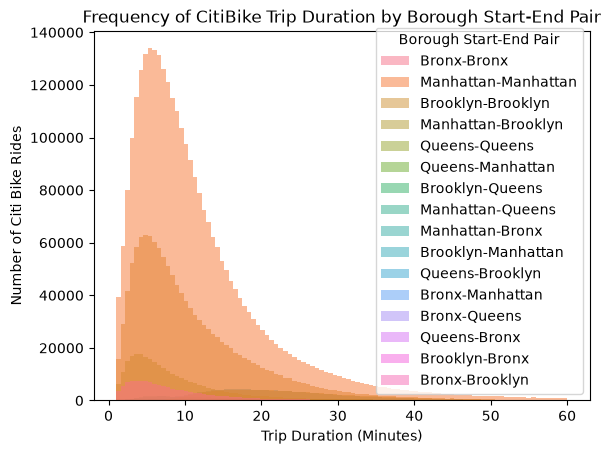

In [51]:
# Explore distribution of Citi Bike trip durations by borough start-end pairs
ax = sns.histplot(data=cb_geo[cb_geo['trip_duration_minutes'] < 60],
             x='trip_duration_minutes',
             hue='boro_start_end',
             bins=100,
             edgecolor=None
             )

ax.set(xlabel="Trip Duration (Minutes)", ylabel="Number of Citi Bike Rides", title='Frequency of CitiBike Trip Duration by Borough Start-End Pair')
sns.move_legend(ax, loc='best', title='Borough Start-End Pair')

plt.show()

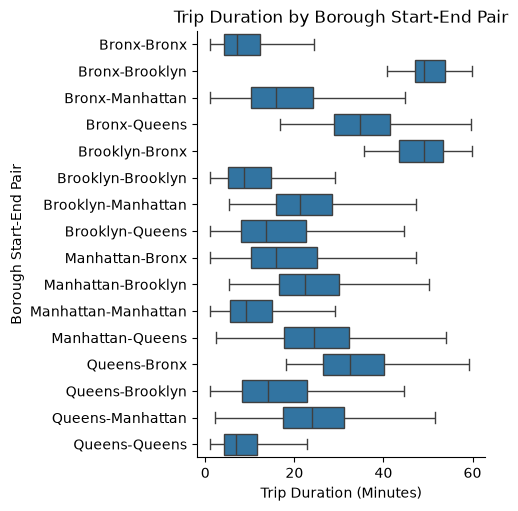

In [52]:
# Explore trip duration distribution with box plots
g = sns.catplot(cb_geo[cb_geo['trip_duration_minutes'] < 60].sort_values(by='boro_start_end'),
            x='trip_duration_minutes',
            y='boro_start_end',
            kind='box',
            showfliers=False
            )

g.ax.set_title('Trip Duration by Borough Start-End Pair')

g.set_axis_labels("Trip Duration (Minutes)", "Borough Start-End Pair")

plt.show()

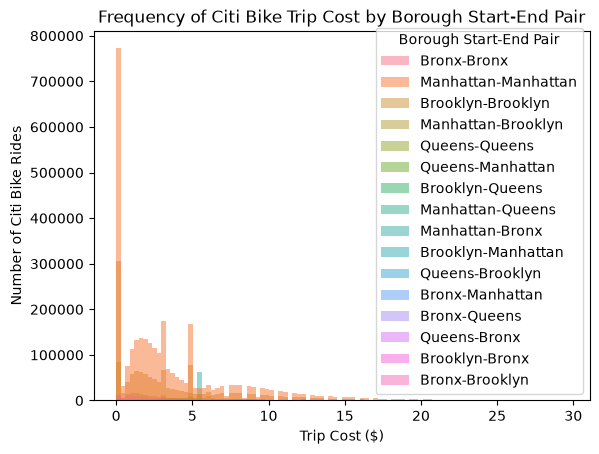

In [53]:
# Explore distribution of Citi Bike trip cost by borough start-end pair
ax = sns.histplot(data=cb_geo[cb_geo['trip_duration_minutes'] < 60],
             x='cost',
             hue='boro_start_end',
             bins=100,
             edgecolor=None
             )

ax.set(xlabel="Trip Cost ($)", ylabel="Number of Citi Bike Rides", title='Frequency of Citi Bike Trip Cost by Borough Start-End Pair')

sns.move_legend(ax, loc='best', title='Borough Start-End Pair')

plt.show()

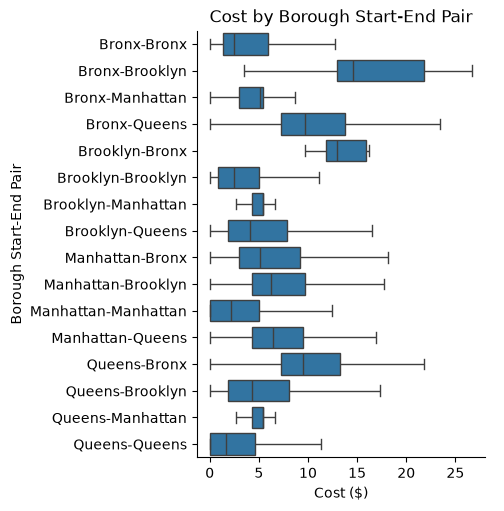

In [54]:
# Explore cost distribution with box plots
g = sns.catplot(cb_geo[cb_geo['trip_duration_minutes'] < 60].sort_values(by='boro_start_end'),
            x='cost',
            y='boro_start_end',
            kind='box',
            showfliers=False
            )

g.ax.set_title('Cost by Borough Start-End Pair')

g.set_axis_labels("Cost ($)", "Borough Start-End Pair")

plt.show()

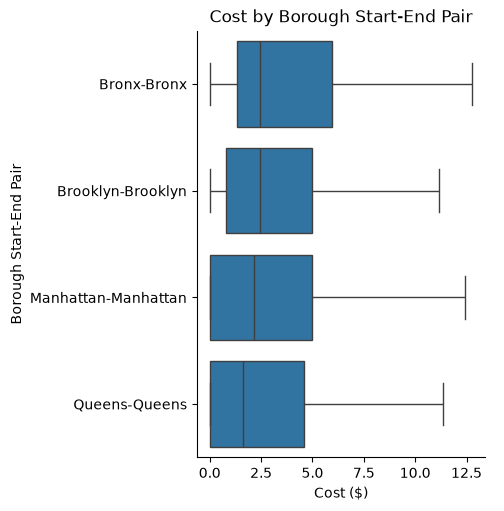

In [55]:
# Explore cost distribution with box plots (only intra-borough trips)
g = sns.catplot(cb_geo[(cb_geo['trip_duration_minutes'] < 60) & (cb_geo['boro_start_end'].isin(['Bronx-Bronx','Brooklyn-Brooklyn','Manhattan-Manhattan','Queens-Queens']))].sort_values(by='boro_start_end'),
            x='cost',
            y='boro_start_end',
            kind='box',
            showfliers=False
            )

g.ax.set_title('Cost by Borough Start-End Pair')

g.set_axis_labels("Cost ($)", "Borough Start-End Pair")

plt.show()

In [56]:
# Inspect distribution of ridership by membership status and rideable_type
pd.pivot_table(
    cb_geo,
    index='member_casual',
    columns='rideable_type',
    aggfunc='count',
    values='ride_id',
    margins=True
)

C:\Users\eturz\AppData\Local\Temp\ipykernel_21468\1561009376.py:2: FutureWarning:

The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior



rideable_type,classic_bike,electric_bike,All
member_casual,,,
casual,266839,829486,1096325
member,1230523,3037087,4267610
All,1497362,3866573,5363935


In [57]:
# Inspect median trip duration by membership status and rideable_type
pd.pivot_table(
    cb_geo,
    index='member_casual',
    columns='rideable_type',
    aggfunc='median',
    values='trip_duration_minutes',
    margins=True
).round(2)

C:\Users\eturz\AppData\Local\Temp\ipykernel_21468\1744462584.py:2: FutureWarning:

The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior



rideable_type,classic_bike,electric_bike,All
member_casual,,,
casual,15.46,12.71,13.31
member,8.05,9.37,9.00
All,9.05,10.00,9.75


In [58]:
# Inspect median cost by membership status and rideable_type
pd.pivot_table(
    cb_geo,
    index='member_casual',
    columns='rideable_type',
    aggfunc='mean',
    values='cost',
    margins=True
).round(2)

C:\Users\eturz\AppData\Local\Temp\ipykernel_21468\1786536525.py:2: FutureWarning:

The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior



rideable_type,classic_bike,electric_bike,All
member_casual,,,
casual,6.34,12.40,10.93
member,0.05,3.35,2.40
All,1.17,5.29,4.14


In [59]:
# Inspect cost by borough start-end pair and bike type
pd.pivot_table(
    cb_geo,
    index='boro_start_end',
    columns='rideable_type',
    aggfunc='mean',
    values='cost',
    margins=True
).sort_values(by='All', ascending=False).round(2).head(20)

C:\Users\eturz\AppData\Local\Temp\ipykernel_21468\3745964311.py:2: FutureWarning:

The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior



rideable_type,classic_bike,electric_bike,All
boro_start_end,,,
Brooklyn-Bronx,21.62,22.30,22.29
Bronx-Brooklyn,11.49,22.51,22.10
Queens-Bronx,4.40,13.13,12.70
Bronx-Queens,3.46,13.07,12.02
Manhattan-Brooklyn,2.29,8.54,7.85
Manhattan-Queens,1.44,8.70,7.67
Manhattan-Bronx,1.93,7.79,7.42
Brooklyn-Manhattan,2.15,7.21,6.71
Bronx-Manhattan,1.89,6.66,6.37


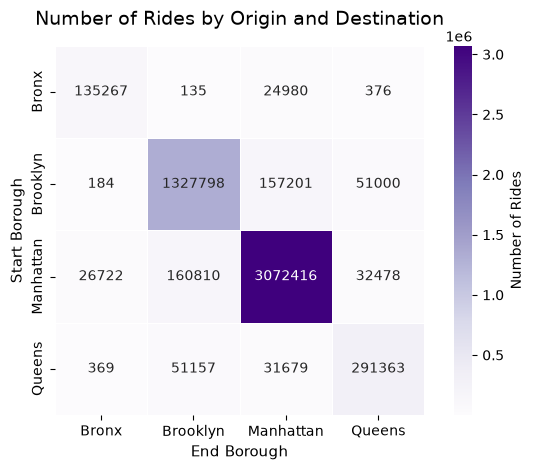

In [60]:
# Create a heatmap showing the number of rides to/from each borough pair
ride_matrix = pd.pivot_table(
    cb_geo,
    index='start_boroname',
    columns='end_boroname',
    aggfunc='count',
    values='ride_id'
)

sns.heatmap(
    ride_matrix,
    annot=True,
    fmt=".0f",
    cmap="Purples",
    square=True,
    linewidths=0.5,
    cbar_kws={"label": "Number of Rides"},
)

plt.title(
    "Number of Rides by Origin and Destination", fontsize=14, pad=15
)
plt.xlabel("End Borough", fontsize=11)
plt.ylabel("Start Borough", fontsize=11)

plt.tight_layout()
plt.show()

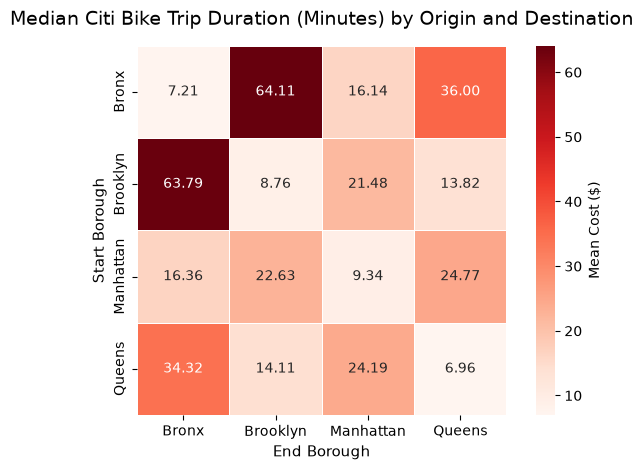

In [61]:
# Create a heatmap showing the time cost of traveling to/from each borough pair
time_matrix = pd.pivot_table(
    cb_geo,
    index='start_boroname',
    columns='end_boroname',
    aggfunc='median',
    values='trip_duration_minutes'
)

sns.heatmap(
    time_matrix,
    annot=True,
    fmt=".2f",
    cmap="Reds",
    square=True,
    linewidths=0.5,
    cbar_kws={"label": "Mean Cost ($)"},
)

plt.title(
    "Median Citi Bike Trip Duration (Minutes) by Origin and Destination", fontsize=14, pad=15
)
plt.xlabel("End Borough", fontsize=11)
plt.ylabel("Start Borough", fontsize=11)

plt.tight_layout()
plt.show()

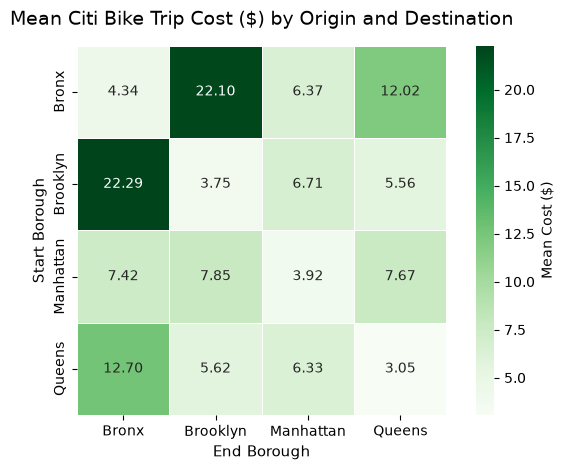

In [62]:
# Create a heatmap showing the financial cost of traveling to/from each borough pair
cost_matrix = pd.pivot_table(
    cb_geo,
    index='start_boroname',
    columns='end_boroname',
    aggfunc='mean',
    values='cost'
)

sns.heatmap(
    cost_matrix,
    annot=True,
    fmt=".2f",
    cmap="Greens",
    square=True,
    linewidths=0.5,
    cbar_kws={"label": "Mean Cost ($)"},
)

plt.title(
    "Mean Citi Bike Trip Cost ($) by Origin and Destination", fontsize=14, pad=15
)
plt.xlabel("End Borough", fontsize=11)
plt.ylabel("Start Borough", fontsize=11)

plt.tight_layout()
plt.show()

## 1.5 Initial Observations of Citi Bike Data
1. Intra-borough trips are the most common trip types. As expected, they bear a lower time and financial cost than inter-borough trips. Other common trip patterns are between Brooklyn and Manhattan, and between Brooklyn and Queens.
2. Intra-Queens trips bear the lowest time and financial cost of all origin-destination pairs, and are made relatively frequently. This could be because Citi Bikes play a greater role in filling gaps in the transit network in Queens than elsewhere and are therefore relied upon for disproportionately short rides.
3. Trips between the Bronx and Queens, and the Bronx and Brooklyn, are extremely rare. While the rarity of trips between the Bronx and Brooklyn is to be expected given that they are furthest from each other, the rarity of trips between the Bronx and Queens may initially be surprising. This is likely attributable to the fact that there is only one bike path, the one across Randall's Island, connecting the two boroughs, and this bike path is steep, circuitous, and includes stairs. While less likely, it could also be attributable to fewer connections between communities in the Queens and the Bronx.

# 2 Process Block Group data

## 2.1 Load Block Group Data

In [63]:
# Define filepath
filepath = r'../data/NYC_Block_Groups_2016_2020/NYC_Block_Groups_2016_2020.shp'

# Read in block group data as a GeoDataFrame
bg = gpd.read_file(filepath)

# Inspect
bg.head(1)

,GISJOIN,STATEFP,COUNTYFP,TRACTCE,BLKGRPCE,GEOID,NAMELSAD,MTFCC,FUNCSTAT,ALAND,...,pctBA_degr,pctGraduat,MHI,HsngUnits,MedRent,MedHsngVal,GISjoinBG1,Field25,year,geometry
0,G36000500001001,36,005,000100,1,360050001001,Block Group 1,G5030,S,1677210.0,...,1.609544,0.35978,0,0,0,0,G36000500001001,None,ACS2016-2021,"POLYGON ((593905.023 4516933.722, 594160.523 4..."


In [64]:
# Inspect CRS
bg.crs

<Projected CRS: EPSG:26918>
Name: NAD83 / UTM zone 18N
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: North America - between 78°W and 72°W - onshore and offshore. Canada - Nunavut; Ontario; Quebec. United States (USA) - Connecticut; Delaware; Maryland; Massachusetts; New Hampshire; New Jersey; New York; North Carolina; Pennsylvania; Virginia; Vermont.
- bounds: (-78.0, 28.28, -72.0, 84.0)
Coordinate Operation:
- name: UTM zone 18N
- method: Transverse Mercator
Datum: North American Datum 1983
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

In [65]:
# Reproject to EPSG 2263
bg = bg.to_crs(epsg=4326)

# Inspect
bg.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [66]:
# Inspect available columns
bg.columns

# Relevant columns:
    # Unique key: GEOID
    # Geometry: geometry
    # Population: Pop1620
    # Income: MHI, MedRent, MedHsngVal
    # Commutes: pctCarComm, pctTransCo, pctWlkBikC
    # Education: pctNoDiplo, pctDiploma, pctCollege, pctBA_degr, pctGraduat
    # Race/Ethnicity: pop_white, pop_black, pop_native, pop_asian, popHispanic, pct_white, pct_black, pct_native, pct_asian, pct_hispan

Index(['GISJOIN', 'STATEFP', 'COUNTYFP', 'TRACTCE', 'BLKGRPCE', 'GEOID',
       'NAMELSAD', 'MTFCC', 'FUNCSTAT', 'ALAND', 'AWATER', 'INTPTLAT',
       'INTPTLON', 'Shape_Leng', 'Shape_Le_1', 'Shape_Area', 'GISJoin_BG',
       'Observatio', 'Pop1620', 'pop_white', 'pop_black', 'pop_native',
       'pop_asian', 'popHipanic', 'pct_white', 'pct_black', 'pct_native',
       'pct_asian', 'pct_hispan', 'pctCarComm', 'pctTransCo', 'pctWlkBikC',
       'pctNoDiplo', 'pctDiploma', 'pctCollege', 'pctBA_degr', 'pctGraduat',
       'MHI', 'HsngUnits', 'MedRent', 'MedHsngVal', 'GISjoinBG1', 'Field25',
       'year', 'geometry'],
      dtype='object')

In [67]:
# Rename popHipanic -> popHispanic
bg.rename(columns={'popHipanic': 'popHispanic'}, inplace=True)

In [68]:
# Inspect shape of GeoDataFrame
bg.shape

(6592, 45)

In [69]:
# Confirm that GEOID is unique to each record
bg['GEOID'].nunique()

6592

In [70]:
# Define columns to keep
cols_to_keep = [
    'GEOID', # Unique key
    'geometry', # Geometry
    'Pop1620', # Total population
    'MHI', # Income
    'pop_white', 'pop_black', 'pop_native', 'pop_asian', 'popHispanic', # Race/ethnicity, population
    'pct_white', 'pct_black', 'pct_native', 'pct_asian', 'pct_hispan' # Race/ethnicity, percentage of total population
]

# Drop unnecessary columns
bg = bg[cols_to_keep]

# Inspect
bg.head(1)

,GEOID,geometry,Pop1620,MHI,pop_white,pop_black,pop_native,pop_asian,popHispanic,pct_white,pct_black,pct_native,pct_asian,pct_hispan
0,360050001001,"POLYGON ((-73.88683 40.79804, -73.88384 40.795...",6600,0,817,3441,27,171,2315,12.378788,52.136364,0.409091,2.590909,35.075758


In [71]:
# Cleaning: Drop records where Pop1620 is 0 (might represent parks or erroneous data)
bg = bg[bg['Pop1620'] != 0]

# Check on shape
bg.shape

(6392, 14)

In [72]:
bg.dtypes

GEOID            object
geometry       geometry
Pop1620           int64
MHI               int64
pop_white         int64
pop_black         int64
pop_native        int64
pop_asian         int64
popHispanic       int64
pct_white       float64
pct_black       float64
pct_native      float64
pct_asian       float64
pct_hispan      float64
dtype: object

In [73]:
bg['MHI'] = pd.to_numeric(bg['MHI'])

## 2.2 Explore Block Group Data

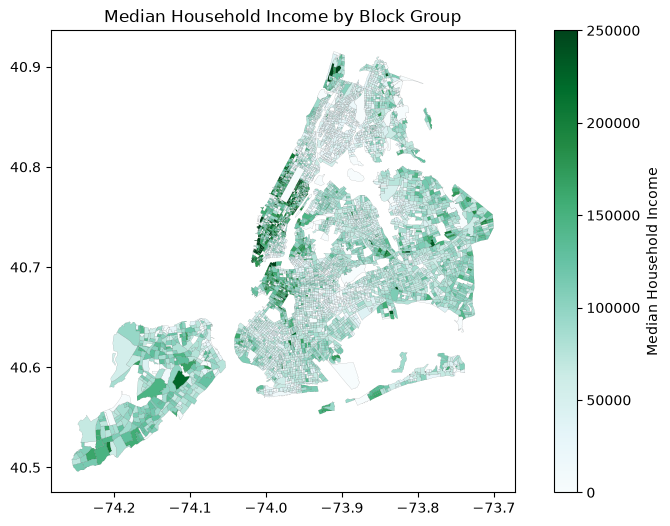

In [74]:
# Explore block groups by Median Household Income
fig, ax = plt.subplots(figsize=(10, 6))
bg.plot(
    ax=ax,
    edgecolor='black',
    column='MHI',
    cmap='BuGn',
    linewidth=0.05,
    legend=True,
    legend_kwds={
        'label':'Median Household Income'
        }
)

plt.title('Median Household Income by Block Group')
plt.show()

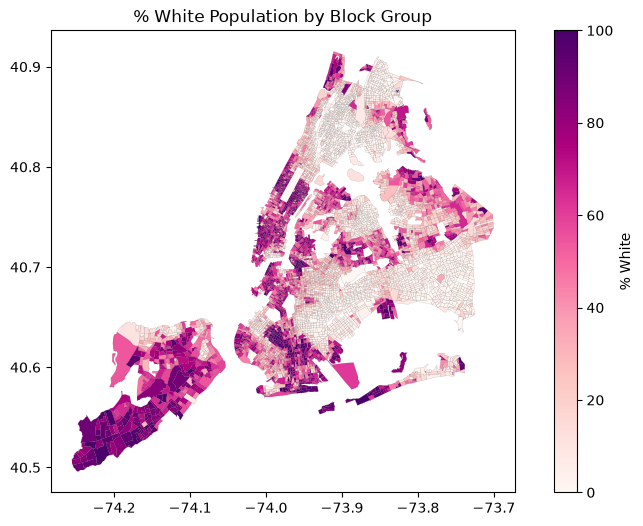

In [75]:
# Explore block groups by race (% Black)
fig, ax = plt.subplots(figsize=(10, 6))
bg.plot(
    ax=ax,
    edgecolor='black',
    column='pct_white',
    cmap='RdPu',
    linewidth=0.05,
    legend=True,
    legend_kwds={
        'label':'% White'
        }
)

plt.title('% White Population by Block Group')
plt.show()

# 3 Combine Citi Bike and Block Group data via spatial join

## 3.1 Spatial Join

We want to join each Citi Bike ride with the block group *within* which it originated. In other words, we need to determine which block group contains the start station point.

In [76]:
# Confirm that projection systems match
cb_geo.crs == bg.crs

True

In [77]:
# Perform spatial join
cb_bg_geo = cb_geo.sjoin( # cb_geo is the "host" GeoDataFrame
    bg[['geometry','GEOID']], # bg is the "guest" GeoDataFrame; only GEOID is needed for now
    how='left',
    predicate='within', # Identify the block group within which each ride originated
    lsuffix='_cb',
    rsuffix='_bg'
)

# Drop index__bg
cb_bg_geo.drop(columns=['index__bg'], inplace=True)

# Inspect result
cb_bg_geo.head(2)

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,...,start_geom,end_geom,start_boroname,start_borocode,end_boroname,end_borocode,mn_enter_exit,boro_start_end,cost,GEOID
0,97F85C640A1C96E2,electric_bike,2026-06-02 14:51:58.403,2026-06-02 15:02:00.255,Concourse Village West & E 156 St,7962.01,Sheridan Ave & E 168 St,8160.03,40.823162,-73.923267,...,POINT (-73.92327 40.82316),POINT (-73.9154 40.83533),Bronx,2.0,Bronx,2.0,NaN,Bronx-Bronx,2.97,360050179013
1,C5DB88A406DCF0B2,electric_bike,2026-06-05 06:57:02.312,2026-06-05 07:03:16.817,West End Ave & W 60 St,7059.08,W 52 St & 6 Ave,6740.01,40.772370,-73.990050,...,POINT (-73.99005 40.77237),POINT (-73.97982 40.76133),Manhattan,1.0,Manhattan,1.0,NaN,Manhattan-Manhattan,1.89,360610131002


In [78]:
# Inspect columns to confirm that join was successful
cb_bg_geo.columns

Index(['ride_id', 'rideable_type', 'started_at', 'ended_at',
       'start_station_name', 'start_station_id', 'end_station_name',
       'end_station_id', 'start_lat', 'start_lng', 'end_lat', 'end_lng',
       'member_casual', 'trip_duration', 'trip_duration_minutes', 'start_geom',
       'end_geom', 'start_boroname', 'start_borocode', 'end_boroname',
       'end_borocode', 'mn_enter_exit', 'boro_start_end', 'cost', 'GEOID'],
      dtype='object')

In [79]:
# Inspect unique values in GEOID (i.e. how many block groups are represented in dataset)
cb_bg_geo['GEOID'].nunique()

1595

## 3.2 Aggregate Citi Bike Data by Block Group

In [80]:
# Prep data to get counts of rides per block group by bike type and membership status
cb_bg_geo = pd.get_dummies(
    cb_bg_geo,
    columns=['rideable_type','member_casual']
)

cb_bg_geo.columns

Index(['ride_id', 'started_at', 'ended_at', 'start_station_name',
       'start_station_id', 'end_station_name', 'end_station_id', 'start_lat',
       'start_lng', 'end_lat', 'end_lng', 'trip_duration',
       'trip_duration_minutes', 'start_geom', 'end_geom', 'start_boroname',
       'start_borocode', 'end_boroname', 'end_borocode', 'mn_enter_exit',
       'boro_start_end', 'cost', 'GEOID', 'rideable_type_classic_bike',
       'rideable_type_electric_bike', 'member_casual_casual',
       'member_casual_member'],
      dtype='object')

In [81]:
# Define aggregation rules
aggs = {
    'ride_id': 'count', # Total number of rides per block group
    'trip_duration_minutes': 'median', # Median trip duration per block group
    'cost': 'mean', # Mean trip cost
    'rideable_type_classic_bike': 'sum', # Total number of classic bike rides per block group
    'rideable_type_electric_bike': 'sum', # Total number of electric bike rides per block group
    'member_casual_casual': 'sum', # Total number of casual (non-member) bike rides per block group
    'member_casual_member': 'sum' # Total number of member bike rides per block group
}

# Perform aggregation
trip_dur_by_bg = cb_bg_geo.groupby('GEOID', as_index=False).agg(aggs)

# Rename columns
trip_dur_by_bg.rename(
    columns = {
        'ride_id':'num_rides',
        'trip_duration_minutes':'median_trip_dur_min',
        'cost':'mean_trip_cost',
        'rideable_type_classic_bike':'num_rides_classic',
        'rideable_type_electric_bike':'num_rides_electric',
        'member_casual_casual':'num_rides_casual',
        'member_casual_member':'num_rides_member'},
    inplace=True
    )

# Inspect
trip_dur_by_bg

,GEOID,num_rides,median_trip_dur_min,mean_trip_cost,num_rides_classic,num_rides_electric,num_rides_casual,num_rides_member
0,360050019011,1911,10.300,5.182826,242,1669,427,1484
1,360050019021,2245,11.000,5.068846,377,1868,484,1761
2,360050023003,1024,10.175,5.221777,116,908,225,799
3,360050025001,766,7.570,4.390457,104,662,196,570
4,360050025002,293,11.750,5.757167,39,254,81,212
...,...,...,...,...,...,...,...,...
1590,360810745002,125,7.810,6.297200,61,64,72,53
1591,360810747001,123,8.810,6.806992,47,76,60,63
1592,360810747002,85,6.630,6.247647,39,46,39,46
1593,360810757021,10,17.940,9.754000,3,7,3,7


## 3.3 Left Join to Get All Relevant Block Group Characteristics 

In [82]:
# Join again to get all block group characteristics
cb_final = pd.merge(
                    trip_dur_by_bg, 
                    bg,
                    on='GEOID',
                    how='left', # We only care about the block groups that appeared in the Citi Bike data
                    validate='1:1'
                    )

# Inspect
cb_final.head()

,GEOID,num_rides,median_trip_dur_min,mean_trip_cost,num_rides_classic,num_rides_electric,num_rides_casual,num_rides_member,geometry,Pop1620,...,pop_white,pop_black,pop_native,pop_asian,popHispanic,pct_white,pct_black,pct_native,pct_asian,pct_hispan
0,360050019011,1911,10.300,5.182826,242,1669,427,1484,"POLYGON ((-73.92652 40.80816, -73.92551 40.807...",1910,...,259,778,0,0,1029,13.560209,40.732984,0.000000,0.000000,53.874346
1,360050019021,2245,11.000,5.068846,377,1868,484,1761,"POLYGON ((-73.90605 40.80337, -73.90722 40.804...",1334,...,201,440,35,59,640,15.067466,32.983508,2.623688,4.422789,47.976012
2,360050023003,1024,10.175,5.221777,116,908,225,799,"POLYGON ((-73.92338 40.80843, -73.92384 40.807...",1457,...,6,586,4,0,1019,0.411805,40.219629,0.274537,0.000000,69.938229
3,360050025001,766,7.570,4.390457,104,662,196,570,"POLYGON ((-73.91922 40.80756, -73.91748 40.806...",929,...,7,51,0,6,868,0.753498,5.489774,0.000000,0.645856,93.433800
4,360050025002,293,11.750,5.757167,39,254,81,212,"POLYGON ((-73.91796 40.80612, -73.91882 40.804...",1185,...,9,633,0,0,671,0.759494,53.417722,0.000000,0.000000,56.624473


In [83]:
# Create rides_per_capita cols
cb_final.loc[:, 'rides_per_capita'] = cb_final['num_rides'] / cb_final['Pop1620'] * 100
cb_final.loc[:, 'rides_per_capita_classic'] = cb_final['num_rides_classic'] / cb_final['Pop1620'] * 100
cb_final.loc[:, 'rides_per_capita_electric'] = cb_final['num_rides_electric'] / cb_final['Pop1620'] * 100
cb_final.loc[:, 'rides_per_capita_casual'] = cb_final['num_rides_casual'] / cb_final['Pop1620'] * 100
cb_final.loc[:, 'rides_per_capita_member'] = cb_final['num_rides_member'] / cb_final['Pop1620'] * 100

# Inspect
cb_final[['num_rides','num_rides_classic','num_rides_electric','num_rides_casual','num_rides_member','Pop1620','rides_per_capita','rides_per_capita_classic','rides_per_capita_electric','rides_per_capita_casual','rides_per_capita_member']].head()

,num_rides,num_rides_classic,num_rides_electric,num_rides_casual,num_rides_member,Pop1620,rides_per_capita,rides_per_capita_classic,rides_per_capita_electric,rides_per_capita_casual,rides_per_capita_member
0,1911,242,1669,427,1484,1910,100.052356,12.670157,87.382199,22.356021,77.696335
1,2245,377,1868,484,1761,1334,168.290855,28.260870,140.029985,36.281859,132.008996
2,1024,116,908,225,799,1457,70.281400,7.961565,62.319835,15.442690,54.838710
3,766,104,662,196,570,929,82.454252,11.194833,71.259419,21.097955,61.356297
4,293,39,254,81,212,1185,24.725738,3.291139,21.434599,6.835443,17.890295


In [84]:
# Create pct_rides cols
cb_final.loc[:, 'pct_classic'] = cb_final['num_rides_classic'] / cb_final['num_rides']
cb_final.loc[:, 'pct_electric'] = cb_final['num_rides_electric'] / cb_final['num_rides']
cb_final.loc[:, 'pct_casual'] = cb_final['num_rides_casual'] / cb_final['num_rides']
cb_final.loc[:, 'pct_member'] = cb_final['num_rides_member'] / cb_final['num_rides']

# Inspect
cb_final[['num_rides','num_rides_electric','pct_electric']].head()

,num_rides,num_rides_electric,pct_electric
0,1911,1669,0.873365
1,2245,1868,0.832071
2,1024,908,0.886719
3,766,662,0.864230
4,293,254,0.866894


## 3.4 Brief Visual Exploration of Combined Data

In [85]:
# Convert cb_final to GeoDataFrame
cb_final_geo = gpd.GeoDataFrame(
    data=cb_final,
    geometry='geometry',
    crs='EPSG:4326'
)

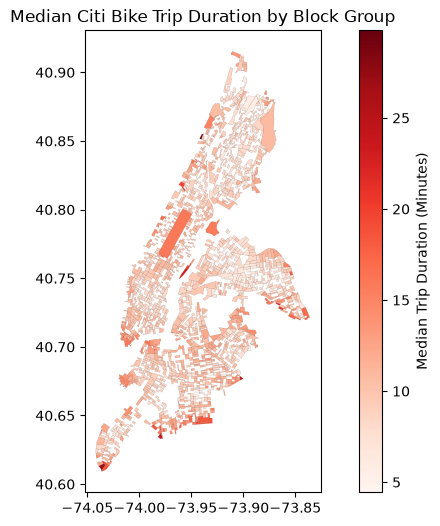

In [86]:
# Explore block groups by Median Citi Bike Trip Duration
fig, ax = plt.subplots(figsize=(10, 6))
cb_final_geo.plot(
    ax=ax,
    edgecolor='black',
    column='median_trip_dur_min',
    cmap='Reds',
    linewidth=0.05,
    legend=True,
    legend_kwds={
        'label':'Median Trip Duration (Minutes)'
        }
)

plt.title('Median Citi Bike Trip Duration by Block Group')
plt.show()

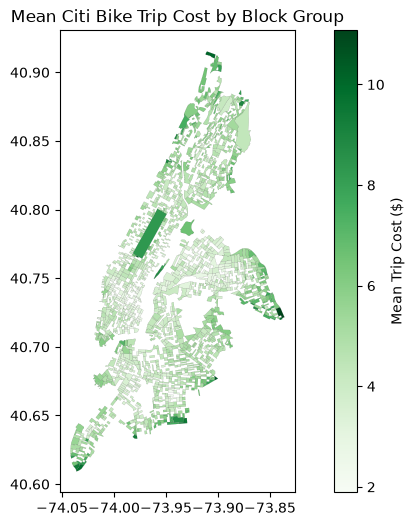

In [87]:
# Explore block groups by Mean CitiBike Trip Cost
fig, ax = plt.subplots(figsize=(10, 6))
cb_final_geo.plot(
    ax=ax,
    edgecolor='black',
    column='mean_trip_cost',
    cmap='Greens',
    linewidth=0.05,
    legend=True,
    legend_kwds={
        'label':'Mean Trip Cost ($)'
        }
)

plt.title('Mean Citi Bike Trip Cost by Block Group')
plt.show()

In [88]:
# Free up memory
del cb_final_geo

# 4 Hypothesis Testing

## 4.1 Median Household Income

### 4.1.1 Frequency

Hypothesis: Higher median household income is significantly associated with increased Citi Bike ride frequency per capita.

N<sub>0</sub>: Higher median household income is not significantly associated with Citi Bike ride frequency per capita.

Test: Ranked Regression (Spearman's Correlation Coefficient). Both variables are continuous and right-skewed. Spearman's Coefficient handles outliers well because it uses rankings of rides per capita and MHI rather than the values themselves.

#### 4.1.1.1 Ranked Regression

In [89]:
# For analysis of MHI's effects, remove block groups where MHI is 0 (assumed to be erroneous)
cb_mhi = cb_final[cb_final['MHI'] > 0]

cb_mhi['MHI'].describe()

count      1414.000000
mean      84344.872702
std       52447.149652
min        7181.000000
25%       47253.750000
50%       72689.000000
75%      107297.000000
max      250001.000000
Name: MHI, dtype: float64

In [90]:
# Explore rides_per_capita outliers
cb_mhi['rides_per_capita'].describe()

count     1414.000000
mean       325.830610
std       1309.659116
min          0.153492
25%         37.771861
50%        108.670958
75%        336.576808
max      35727.450980
Name: rides_per_capita, dtype: float64

In [91]:
# Explore distribution of MHI (right-skewed)
fig = px.histogram(
    cb_mhi,
    x='MHI',
    nbins=50,
    title='Number of Block Groups by Median Household Income',
    labels={'MHI':'Median Household Income','count':'# of Block Groups'},
    marginal='box',
    width=500,
    height=400,
    color_discrete_sequence=['green']
)

fig.update_layout(title_x=0.5)
fig.update_layout(yaxis_title="# of Block Groups")

fig.show()

In [92]:
# Explore distribution of ride frequency (right-skewed)
fig = px.histogram(
    cb_mhi,
    x='rides_per_capita',
    nbins=50,
    title='Number of Block Groups by Citi Bike Ride Frequency Per Capita',
    labels={'num_rides':'# of Rides Per Capita','count':'# of Block Groups'},
    marginal='box',
    width=600,
    height=400
)

fig.update_layout(title_x=0.5)
fig.update_layout(yaxis_title="# of Block Groups")

fig.show()

In [93]:
# Explore relationship via scatterplot
fig = px.scatter(
    cb_mhi,
    x="MHI",
    y="rides_per_capita",
    trendline="ols",
    width=800,
    height=600,
    title='Citi Bike Rides per Capita by Median Household Income',
    labels={'MHI':'Median Household Income', 'rides_per_capita':'Rides Per Capita'},
    opacity=0.25,
    marginal_x='histogram',
    marginal_y='histogram'
    )

fig.update_layout(title_x=0.5)

fig.show()

In [94]:
# Since MHI and rides per capita have non-normal distributions, use ranking
cb_mhi.loc[:, 'MHI_ranked'] = cb_mhi['MHI'].rank(ascending=False)
cb_mhi.loc[:, 'rpc_ranked'] = cb_mhi['rides_per_capita'].rank(ascending=False)

# Inspect
cb_mhi[['rides_per_capita','rpc_ranked']].sort_values('rides_per_capita', ascending=False).head()

C:\Users\eturz\AppData\Local\Temp\ipykernel_21468\2840801629.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\eturz\AppData\Local\Temp\ipykernel_21468\2840801629.py:3: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,rides_per_capita,rpc_ranked
1006,35727.450980,1.0
973,29293.333333,2.0
998,8551.207729,3.0
23,4613.698630,4.0
984,3737.887067,5.0


In [95]:
# Run Ordinary Least Squares regression on ranked data
results = smf.ols("rpc_ranked ~ MHI_ranked", data=cb_mhi).fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:             rpc_ranked   R-squared:                       0.264
Model:                            OLS   Adj. R-squared:                  0.264
Method:                 Least Squares   F-statistic:                     507.3
Date:                Tue, 25 Aug 2026   Prob (F-statistic):           3.20e-96
Time:                        19:40:16   Log-Likelihood:                -10290.
No. Observations:                1414   AIC:                         2.058e+04
Df Residuals:                    1412   BIC:                         2.059e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    343.7709     18.645     18.438      0.0

#### 4.1.1.2 Interpretation

In [96]:
#| echo: false

print(f"""The Spearman correlation coefficient between MHI and rides
per capita is {round(results.params.iloc[1],4)}, suggesting a moderate positive
relationship between these variables. In other words, as
MHI in a block group increases, ride frequency per capita
increases moderately. MHI explains {round(results.rsquared * 100, 2)}% of the variability
in Citi Bike frequency per capita. The p-values of < 0.001
suggest that this relationship is statistically significant;
that is, there is less than a 0.1% chance that a Type I Error
will be made by rejecting the null hypothesis. The null
hypothesis is rejected.""")

The Spearman correlation coefficient between MHI and rides
per capita is 0.5141, suggesting a moderate positive
relationship between these variables. In other words, as
MHI in a block group increases, ride frequency per capita
increases moderately. MHI explains 26.43% of the variability
in Citi Bike frequency per capita. The p-values of < 0.001
suggest that this relationship is statistically significant;
that is, there is less than a 0.1% chance that a Type I Error
will be made by rejecting the null hypothesis. The null
hypothesis is rejected.


### 4.1.2 Time Cost

Hypothesis: Lower median household income is significantly associated with longer median Citi Bike trip durations.

N<sub>0</sub>: Lower median household income is not significantly associated with longer median Citi Bike trip durations.

Test: Ranked Regression (Spearman's Correlation Coefficient). Both variables are continuous and one is right-skewed. Spearman's Coefficient handles outliers well because it uses rankings of trip cost and MHI rather than the values themselves.

Result: Null hypothesis rejected. Relationship between variables is opposite of what was hypothesized.

#### 4.1.2.1 Ranked Regression

In [97]:
# Explore distribution of median trip duration (normal)
fig = px.histogram(
    cb_mhi,
    x='median_trip_dur_min',
    nbins=50,
    title='Number of Block Groups by Median Citi Bike Trip Duration',
    labels={'median_trip_dur_min':'Median Citi Bike Trip Duration (Minutes)','count':'# of Block Groups'},
    marginal='box',
    width=500,
    height=400
)

fig.update_layout(title_x=0.5)
fig.update_layout(yaxis_title="# of Block Groups")

fig.show()

In [98]:
# Explore relationship via scatterplot
fig = px.scatter(
    cb_mhi,
    x="MHI",
    y="median_trip_dur_min",
    trendline="ols",
    width=800,
    height=600,
    title='Median Citi Bike Trip Duration by Median Household Income',
    labels={'MHI':'Median Household Income', 'median_trip_dur_min':'Median Trip Duration (Minutes)'},
    opacity=0.25,
    marginal_x='histogram',
    marginal_y='histogram'
    )

fig.update_layout(title_x=0.5)

fig.show()

In [99]:
# Since MHI distribution is non-normal, use ranking
# cb_mhi.loc[:, 'MHI_ranked'] = cb_mhi['MHI'].rank(ascending=False)
cb_mhi.loc[:, 'dur_ranked'] = cb_mhi['median_trip_dur_min'].rank(ascending=False)

# Inspect
cb_mhi[['median_trip_dur_min','dur_ranked']].sort_values('median_trip_dur_min', ascending=False).head()

C:\Users\eturz\AppData\Local\Temp\ipykernel_21468\2639046968.py:3: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,median_trip_dur_min,dur_ranked
1243,29.805,1.0
315,27.040,2.0
637,23.800,3.0
1564,21.640,4.0
1566,20.625,5.0


In [100]:
# Run Ordinary Least Squares regression on ranked data
results = smf.ols("dur_ranked ~ MHI_ranked", data=cb_mhi).fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:             dur_ranked   R-squared:                       0.005
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     7.387
Date:                Tue, 25 Aug 2026   Prob (F-statistic):            0.00665
Time:                        19:40:16   Log-Likelihood:                -10503.
No. Observations:                1414   AIC:                         2.101e+04
Df Residuals:                    1412   BIC:                         2.102e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    656.4616     21.681     30.279      0.0

#### 4.1.2.2 Interpretation

In [101]:
#| echo: false

print(f"""The Spearman correlation coefficient between MHI and median trip
duration is {round(results.params.iloc[1],4)}, suggesting an extremely weak positive
relationship between these variables. In other words, as MHI in a
block group increases, median Citi Bike trip duration increases
only very slightly. MHI explains {round(results.rsquared * 100, 2)}% of the variability in Citi
Bike trip duration. The p-values of < 0.001 suggest that this
relationship is statistically significant; that is, there is less
than a 0.1% chance that a Type I Error will be made by rejecting
the null hypothesis. The null hypothesis is rejected, but the
relationship between variables was the opposite of what was
hypothesized.""")

The Spearman correlation coefficient between MHI and median trip
duration is 0.0721, suggesting an extremely weak positive
relationship between these variables. In other words, as MHI in a
block group increases, median Citi Bike trip duration increases
only very slightly. MHI explains 0.52% of the variability in Citi
Bike trip duration. The p-values of < 0.001 suggest that this
relationship is statistically significant; that is, there is less
than a 0.1% chance that a Type I Error will be made by rejecting
the null hypothesis. The null hypothesis is rejected, but the
relationship between variables was the opposite of what was
hypothesized.


### 4.1.3 Financial Cost

Hypothesis: Lower median household income is significantly associated with higher cost Citi Bike rides.

N<sub>0</sub>: Lower median household income is not significantly associated with higher cost Citi Bike rides.

Test: Ranked Regression (Spearman's Correlation Coefficient). Both variables are continuous and right-skewed. Spearman's Coeffient handles outliers well because it uses rankings of trip cost and MHI rather than the values themselves.

Result: Null hypothesis rejected.

#### 4.1.3.1 Ranked Regression

In [102]:
# Explore distribution of mean trip cost (slightly right-skewed)
fig = px.histogram(
    cb_mhi,
    x='mean_trip_cost',
    nbins=50,
    title='Number of Block Groups by Mean Citi Bike Trip Cost',
    labels={'mean_trip_cost':'Mean Citi Bike Trip Cost ($)','count':'# of Block Groups'},
    marginal='box',
    width=500,
    height=400,
)

fig.update_layout(title_x=0.5)
fig.update_layout(yaxis_title="# of Block Groups")

fig.show()

In [103]:
# Explore relationship via scatterplot
fig = px.scatter(
    cb_mhi,
    x="MHI",
    y="mean_trip_cost",
    trendline="ols",
    width=800,
    height=600,
    title='Mean Citi Bike Trip Cost by Median Household Income',
    labels={'mean_trip_cost':'Mean Trip Cost ($)', 'MHI':'Median Household Income'},
    opacity=0.25,
    marginal_x='histogram',
    marginal_y='histogram'
    )

fig.update_layout(title_x=0.5)

fig.show()

In [104]:
# Since MHI distribution is non-normal, use ranking
cb_mhi.loc[:, 'cost_ranked'] = cb_mhi['mean_trip_cost'].rank(ascending=False)

# Inspect
cb_mhi[['mean_trip_cost','cost_ranked']].sort_values('mean_trip_cost', ascending=False).head()

C:\Users\eturz\AppData\Local\Temp\ipykernel_21468\3534667283.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,mean_trip_cost,cost_ranked
1594,11.075172,1.0
1048,10.345030,2.0
415,9.765726,3.0
1593,9.754000,4.0
756,9.428456,5.0


In [105]:
# Run Ordinary Least Squares regression on ranked data
results = smf.ols("cost_ranked ~ MHI_ranked", data=cb_mhi).fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:            cost_ranked   R-squared:                       0.075
Model:                            OLS   Adj. R-squared:                  0.074
Method:                 Least Squares   F-statistic:                     113.9
Date:                Tue, 25 Aug 2026   Prob (F-statistic):           1.26e-25
Time:                        19:40:16   Log-Likelihood:                -10452.
No. Observations:                1414   AIC:                         2.091e+04
Df Residuals:                    1412   BIC:                         2.092e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    900.7986     20.910     43.079      0.0

#### 4.1.3.2 Interpretation

In [106]:
#| echo: false

print(f"""The Spearman correlation coefficient between MHI and mean trip cost
is {round(results.params.iloc[1],4)}, suggesting a weak negative relationship between these
variables. In other words, as MHI in a block group decreases, mean
Citi Bike trip cost increases slightly. MHI explains {round(results.rsquared * 100, 2)}% of the
variability in Citi Bike trip cost. The p-values of < 0.001 suggest
that this relationship is statistically significant; that is, there is
less than a 0.1% chance that a Type I Error will be made by rejecting
the null hypothesis. Therefore, the null hypothesis is rejected.""")

The Spearman correlation coefficient between MHI and mean trip cost
is -0.2732, suggesting a weak negative relationship between these
variables. In other words, as MHI in a block group decreases, mean
Citi Bike trip cost increases slightly. MHI explains 7.46% of the
variability in Citi Bike trip cost. The p-values of < 0.001 suggest
that this relationship is statistically significant; that is, there is
less than a 0.1% chance that a Type I Error will be made by rejecting
the null hypothesis. Therefore, the null hypothesis is rejected.


## 4.2 Race/Ethnicity

### 4.2.1 Frequency

Hypothesis: Lower percentage population of white people is significantly associated with fewer Citi Bike rides per capita.

N<sub>0</sub>: Lower percentage population of white people is not significantly associated with fewer Citi Bike rides per capita.

Test: Ranked Regression (Spearman's Correlation Coefficient). The dependent variable, number of Citi Bike rides per capita, is a continuous variable, while the independent variable, percentage population of white people, can only vary between 0 (0%) and 1 (100%). To properly fit this, we will use Heteroscedasticity-Robust Standard Errors. Both variables are highly right-skewed, which Spearman's Correlation Coefficient handles well.

Result: Null hypothesis is rejected.

#### 4.2.1.1 Ranked Regression

In [107]:
# Explore distribution of % white population (right-skewed)
fig = px.histogram(
    cb_final,
    x='rides_per_capita',
    nbins=50,
    title='Number of Block Groups by Ride Frequency',
    labels={'num_rides':'# of Rides','count':'# of Block Groups'},
    marginal='box',
    width=500,
    height=400
)

fig.update_layout(title_x=0.5)
fig.update_layout(yaxis_title="# of Block Groups")

fig.show()

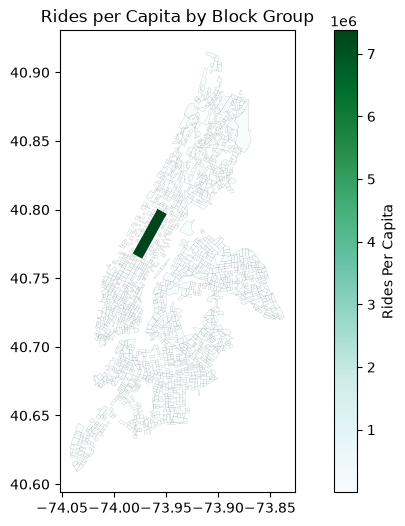

In [108]:
# Explore outliers in rides_per_capita
cb_final_geo = gpd.GeoDataFrame(
    cb_final,
    geometry='geometry',
    crs='EPSG:4326'
)

# Explore block groups by rides_per_capita
fig, ax = plt.subplots(figsize=(10, 6))
cb_final_geo.plot(
    ax=ax,
    edgecolor='black',
    column='rides_per_capita',
    cmap='BuGn',
    linewidth=0.05,
    legend=True,
    legend_kwds={
        'label':'Rides Per Capita'
        }
)

plt.title('Rides per Capita by Block Group')
plt.show()

In [109]:
# Remove outliers (Central Park, etc)
cb_final_freq = cb_final[cb_final['rides_per_capita'] < 4000]

In [110]:
# Explore new distribution of rides per capita (right-skewed)
fig = px.histogram(
    cb_final_freq,
    x='rides_per_capita',
    nbins=50,
    title='Number of Block Groups by Ride Frequency',
    labels={'num_rides':'# of Rides','count':'# of Block Groups'},
    marginal='box',
    width=500,
    height=400
)

fig.update_layout(title_x=0.5)
fig.update_layout(yaxis_title="# of Block Groups")

fig.show()

In [111]:
# Explore distribution of % white population (right-skewed)
fig = px.histogram(
    cb_final_freq,
    x='pct_white',
    nbins=50,
    title='Number of Block Groups by Percent White Population',
    labels={'pct_white':'% White','count':'# of Block Groups'},
    marginal='box',
    width=500,
    height=400,
        color_discrete_sequence=['purple']
)

fig.update_layout(title_x=0.5)
fig.update_layout(yaxis_title="# of Block Groups")

fig.show()

In [112]:
# Explore relationship via scatterplot
fig = px.scatter(
    cb_final_freq,
    x="pct_white",
    y="rides_per_capita",
    trendline="ols",
    width=800,
    height=600,
    title='Ride Frequency by Percent White Population',
    labels={'pct_white':'% White', 'num_rides':'# of Rides'},
    opacity=0.25,
    marginal_x='histogram',
    marginal_y='histogram'
    )

fig.update_layout(title_x=0.5)

fig.show()

In [113]:
# Since % white and rides per capita have non-normal distributions, use ranking
cb_final_freq.loc[:, 'pct_white_ranked'] = cb_final_freq['pct_white'].rank(ascending=False)
cb_final_freq.loc[:, 'rpc_ranked'] = cb_final_freq['rides_per_capita'].rank(ascending=False)

# Inspect
cb_final_freq[['rides_per_capita','rpc_ranked']].sort_values('rides_per_capita', ascending=False).head()

C:\Users\eturz\AppData\Local\Temp\ipykernel_21468\2894649725.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\eturz\AppData\Local\Temp\ipykernel_21468\2894649725.py:3: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,rides_per_capita,rpc_ranked
984,3737.887067,1.0
1043,3697.087379,2.0
987,3587.920384,3.0
787,3442.774566,4.0
940,3423.673997,5.0


In [114]:
results = smf.ols(
    formula="rpc_ranked ~ pct_white_ranked",
    data=cb_final_freq
).fit(cov_type='HC3')

print(results.summary())

                            OLS Regression Results                            
Dep. Variable:             rpc_ranked   R-squared:                       0.295
Model:                            OLS   Adj. R-squared:                  0.294
Method:                 Least Squares   F-statistic:                     720.0
Date:                Tue, 25 Aug 2026   Prob (F-statistic):          5.86e-131
Time:                        19:40:17   Log-Likelihood:                -11632.
No. Observations:                1579   AIC:                         2.327e+04
Df Residuals:                    1577   BIC:                         2.328e+04
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept          361.0367     20.257  

#### 4.2.1.2 Interpretation

In [115]:
#| echo: false

print(f"""The correlation coeffient between percentage population of white people
and ride frequency is {round(results.params.iloc[1],4)}, suggesting a moderately positive
relationship between these variables. In other words, as the percentage
of white people in a block group increases, Citi Bike trip frequency
increases moderately. The percentage of white people in a block group
explains {round(results.rsquared * 100, 2)}% of the variability in Citi Bike trip frequency. The
p-values of < 0.001 suggest that this relationship is statistically
significant. The null hypothesis is rejected.""")

The correlation coeffient between percentage population of white people
and ride frequency is 0.543, suggesting a moderately positive
relationship between these variables. In other words, as the percentage
of white people in a block group increases, Citi Bike trip frequency
increases moderately. The percentage of white people in a block group
explains 29.47% of the variability in Citi Bike trip frequency. The
p-values of < 0.001 suggest that this relationship is statistically
significant. The null hypothesis is rejected.


### 4.2.2 Time Cost
Hypothesis: Lower percentage population of white people is significantly associated with longer median Citi Bike trip durations.

N<sub>0</sub>: Lower percentage population of white people is not significantly associated with longer median Citi Bike trip durations.

Test: Ranked Regression. The dependent variable, median Citi Bike trip duration, is a continuous variable, and the independent variable, percentage population of white people, can only vary between 0 (0%) and 1 (100%). To properly fit this, we will use Heteroscedasticity-Robust Standard Errors. Both variables are highly right-skewed, which Spearman's Correlation Coefficient handles well.

Result: Null hypothesis rejected, but relationship between variables is opposite of what was hypothesized.

#### 4.2.2.1 Ranked Regression

In [116]:
# Explore distribution of median CitiBike trip duration
fig = px.histogram(
    cb_final,
    x='median_trip_dur_min',
    nbins=50,
    title='Number of Block Groups by Median Citi Bike Trip Duration',
    labels={'median_trip_dur_min':'Median Trip Duration (Minutes)','count':'# of Block Groups'},
    marginal='box',
    width=500,
    height=400
)

fig.update_layout(title_x=0.5)
fig.update_layout(yaxis_title="# of Block Groups")

fig.show()

In [117]:
# Explore relationship via scatterplot
fig = px.scatter(
    cb_final,
    x="pct_white",
    y="median_trip_dur_min",
    trendline="ols",
    width=800,
    height=600,
    title='Median Citi Bike Trip Duration by Percent White Population',
    labels={'pct_white':'% White', 'median_trip_dur_min':'Median Trip Duration (Minutes)'},
    opacity=0.25,
    marginal_x='histogram',
    marginal_y='histogram'
    )

fig.update_layout(title_x=0.5)

fig.show()

In [118]:
# Since % white has a non-normal distribution, use ranking
cb_final.loc[:, 'pct_white_ranked'] = cb_final['pct_white'].rank(ascending=False)
cb_final.loc[:, 'trip_dur_ranked'] = cb_final['median_trip_dur_min'].rank(ascending=False)

# Inspect
cb_final[['median_trip_dur_min','trip_dur_ranked']].sort_values('median_trip_dur_min', ascending=False).head()

,median_trip_dur_min,trip_dur_ranked
1243,29.805,1.0
315,27.040,2.0
637,23.800,3.0
561,23.610,4.0
1208,22.645,5.0


In [119]:
results = smf.ols(
    formula="trip_dur_ranked ~ pct_white_ranked",
    data=cb_final
).fit(cov_type='HC3')

print(results.summary())

                            OLS Regression Results                            
Dep. Variable:        trip_dur_ranked   R-squared:                       0.014
Model:                            OLS   Adj. R-squared:                  0.014
Method:                 Least Squares   F-statistic:                     23.68
Date:                Tue, 25 Aug 2026   Prob (F-statistic):           1.25e-06
Time:                        19:40:17   Log-Likelihood:                -12033.
No. Observations:                1595   AIC:                         2.407e+04
Df Residuals:                    1593   BIC:                         2.408e+04
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept          703.1274     22.062  

#### 4.2.2.2 Interpretation

In [120]:
#| echo: false

print(f"""The correlation coeffient between percentage population of white people
and median trip duration is {round(results.params.iloc[1],4)}, suggesting an extremely weak positive
relationship between these variables. In other words, as the percentage
of white people in a block group increases, median Citi Bike trip duration
increases very slightly. The percentage of white people in a block group
explains {round(results.rsquared * 100, 2)}% of the variability in median CitiBike trip duration. The
p-values of < 0.001 suggest that this relationship is statistically
significant. The null hypothesis is rejected, as there is an extremely weak
but statistically significant relationship between these variables. However,
the relationship between these variables is the opposite of what was hypothesized.""")

The correlation coeffient between percentage population of white people
and median trip duration is 0.1189, suggesting an extremely weak positive
relationship between these variables. In other words, as the percentage
of white people in a block group increases, median Citi Bike trip duration
increases very slightly. The percentage of white people in a block group
explains 1.41% of the variability in median CitiBike trip duration. The
p-values of < 0.001 suggest that this relationship is statistically
significant. The null hypothesis is rejected, as there is an extremely weak
but statistically significant relationship between these variables. However,
the relationship between these variables is the opposite of what was hypothesized.


### 4.2.3 Financial Cost

Hypothesis: Lower percentage population of white people is significantly associated with higher cost CitiBike rides.

N<sub>0</sub>: Lower percentage population of white people is not significantly associated with higher cost CitiBike rides.

Test: Ranked Regression. The dependent variable, mean CitiBike trip cost, is a continuous variable, and the independent variable, percentage population of white people, can only vary between 0 (0%) and 1 (100%). To properly fit this, we will use Heteroscedasticity-Robust Standard Errors. Both variables are highly right-skewed, which Spearman's Correlation Coefficient handles well.

Result: Null hypothesis rejected.

#### 4.2.3.1 Ranked Regression

In [121]:
# Explore distribution of mean CitiBike trip cost
fig = px.histogram(
    cb_final,
    x='mean_trip_cost',
    nbins=50,
    title='Number of Block Groups by Mean CitiBike Trip Cost',
    labels={'mean_trip_cost':'Mean Trip Cost ($)','count':'# of Block Groups'},
    marginal='box',
    width=500,
    height=400
)

fig.update_layout(title_x=0.5)
fig.update_layout(yaxis_title="# of Block Groups")

fig.show()

In [122]:
# Explore relationship via scatterplot
fig = px.scatter(
    cb_final,
    x="pct_white",
    y="mean_trip_cost",
    trendline="ols",
    width=800,
    height=600,
    title='Mean CitiBike Trip Cost by Percent White Population',
    labels={'mean_trip_cost':'Mean Trip Cost ($)', 'pct_white':'% White'},
    opacity=0.25,
    marginal_x='histogram',
    marginal_y='histogram'
    )

fig.update_layout(title_x=0.5)

fig.show()

In [123]:
# Since % white has a non-normal distribution, use ranking
cb_final.loc[:, 'cost_ranked'] = cb_final['mean_trip_cost'].rank(ascending=False)

# Inspect
cb_final[['mean_trip_cost','cost_ranked']].sort_values('mean_trip_cost', ascending=False).head()

,mean_trip_cost,cost_ranked
1594,11.075172,1.0
561,10.468173,2.0
1048,10.345030,3.0
181,10.112949,4.0
415,9.765726,5.0


In [124]:
results = smf.ols(
    formula="cost_ranked ~ pct_white_ranked",
    data=cb_final
).fit(cov_type='HC3')

print(results.summary())

                            OLS Regression Results                            
Dep. Variable:            cost_ranked   R-squared:                       0.105
Model:                            OLS   Adj. R-squared:                  0.105
Method:                 Least Squares   F-statistic:                     198.1
Date:                Tue, 25 Aug 2026   Prob (F-statistic):           1.68e-42
Time:                        19:40:18   Log-Likelihood:                -11955.
No. Observations:                1595   AIC:                         2.391e+04
Df Residuals:                    1593   BIC:                         2.393e+04
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept         1056.9110     22.435  

#### 4.2.3.2 Interpretation

In [125]:
#| echo: false

print(f"""The correlation coeffient between percentage population of white people
and mean trip cost is {round(results.params.iloc[1],4)}, suggesting a weak negative relationship
between these variables. In other words, as the percentage of white people
in a block group decreases, mean CitiBike trip cost increases slightly.
The percentage of white people in a block group explains {round(results.rsquared * 100, 2)}% of the
variability in CitiBike trip cost. The p-values of < 0.001 suggest that
this relationship is statistically significant; that is, there is less
than a 0.1% chance that a Type I Error will be made by rejecting the null
hypothesis. Therefore, the null hypothesis is rejected.""")

The correlation coeffient between percentage population of white people
and mean trip cost is -0.3244, suggesting a weak negative relationship
between these variables. In other words, as the percentage of white people
in a block group decreases, mean CitiBike trip cost increases slightly.
The percentage of white people in a block group explains 10.52% of the
variability in CitiBike trip cost. The p-values of < 0.001 suggest that
this relationship is statistically significant; that is, there is less
than a 0.1% chance that a Type I Error will be made by rejecting the null
hypothesis. Therefore, the null hypothesis is rejected.


# 5 Interpretation & Conclusion

The analysis supports the hypotheses relating to median household income, suggesting that higher income block groups tend to use Citi Bike with more frequency per capita, bear slightly lower financial costs, and bear slightly lower time costs.

The analysis suggests that whiter block groups tend to use Citi Bike with more frequency per capita and bear slightly lower financial costs. However, results were mixed regarding the time costs of these block groups, which tend to bear time costs that are very slightly higher, the opposite of what was hypothesized. This could be because white individuals, in aggregate, may have greater means to purchase a Citi Bike membership, which grants riders longer periods in which a ride's cost is fixed (45 minutes vs 30 minutes for non-members).

While this analysis was focused on the spatial equity implications of a $3 Citi Bike fare cap, I suspect other variables may have a far greater impact on Citi Bike costs, median trip duration, and trip frequency. Those variables include transit access, car ownership, the length of the nearby bike network, the quality of that network (i.e. [Class I](https://www.nycstreetdesign.info/geometry/protected-bike-lane) vs Class III bike lanes), and the connectivity of that network. Further analysis would be needed to determine the effect of these variables, if any, on Citi Bike frequency, time costs, and financial costs.

Another dimension for future analysis is how much latent demand would be induced by capping the fare at $3. The mode shift towards Citi Bike would almost certainly also reduce use of other modes such as driving, rideshare, and transit use, and may therefore have knock-on effects on traffic congestion, yields from congestion pricing, and farebox returns from transit.

The results of this analysis suggest that Transportation Alternatives's proposed $3 cap on Citi Bike rides would disproportionately benefit marginalized groups by disproportionately reducing the mean cost of Citi Bike rides in these block groups, while also benefitting all riders. This policy would improve spatial equity by lowering time and/or financial costs required to access jobs and services and thereby increasing social mobility for all, particularly those with the least access to those resources at present.

![Illustration of an electric Citi Bike taken from Transportation Alternatives's $3 Citi Bike campaign.](../docs/assets/TA_endcover.png){.preview-image}